## Mean test pass rate

In [128]:
import pandas as pd

df = pd.read_csv("../results/raw_csv/master_analysis.csv")

table = (
    df[df["pass_rate"].notna()]
      .groupby(["model","generation"])["pass_rate"]
      .mean()
      .reset_index()
)

table.to_csv("../results/tables/mean_pass_rate_model_gen.csv", index=False)
table

,model,generation,pass_rate
0,gemma,gen_1,0.464980
1,gemma,gen_2,0.458803
2,gemma,gen_3,0.478618
3,human,soln1,0.831757
4,human,soln2,0.827629
5,llama,gen_1,0.423199
6,llama,gen_2,0.426447
7,llama,gen_3,0.425754
8,qwen,gen_1,0.360750
9,qwen,gen_2,0.382279


### Pass rate vs vulnerability count

In [129]:
master = pd.read_csv("../results/raw_csv/master_analysis.csv")
master.head(2)

,sample_id,model,generation,batch,problem_key,problem_key_source,shard,compile_attempted,compiled,has_tests,...,cppcheck_has_cwe,cppcheck_errors,cppcheck_style,cppcheck_perf,clang_total,clang_warnings,clang_errors,clang_bugprone,clang_performance,clang_analyzer
0,human/soln1/00000/0029_331_E2._Deja_Vu.cpp,human,soln1,00000,331_E2_Deja_Vu,json,0,1,1,1,...,1,0,4,0,30,30,0,15,1,1
1,human/soln1/00000/0032_39_H._Multiplication_Ta...,human,soln1,00000,39_H_Multiplication_Table,json,0,1,1,1,...,0,0,0,0,3,3,0,0,1,0


In [130]:
cppcheck = pd.read_csv("../results/raw_csv/cppcheck_detailed.csv")
cppcheck.head(2)

,sample_id,model,generation,batch,problem_key,error_id,severity,cwe,message
0,human/soln1/00000/0146_p03194_CADDi_2018_for_B...,human,soln1,00000,p03194 caddi 2018 for beginners product and gcd,variableScope,style,398.0,The scope of the variable 'k' can be reduced.
1,human/soln1/00000/0266_1285_C._Fadi_and_LCM,human,soln1,00000,1285 c fadi and lcm,variableScope,style,398.0,The scope of the variable 'a' can be reduced.


In [131]:
# master_analysis already has cppcheck columns merged
# cppcheck_total, cppcheck_warnings, cppcheck_cwe_count, cppcheck_has_cwe

merged = master[["sample_id", "model", "generation", "pass_rate", 
                 "cppcheck_total", "cppcheck_cwe_count"]].copy()
merged = merged[merged["pass_rate"].notna()]
merged.head(2)

,sample_id,model,generation,pass_rate,cppcheck_total,cppcheck_cwe_count
0,human/soln1/00000/0029_331_E2._Deja_Vu.cpp,human,soln1,1.000000,4,1
1,human/soln1/00000/0032_39_H._Multiplication_Ta...,human,soln1,0.142857,0,0


# TPR with TAGS

In [132]:
import pandas as pd

master = pd.read_csv("../results/raw_csv/master_analysis.csv")
master

,sample_id,model,generation,batch,problem_key,problem_key_source,shard,compile_attempted,compiled,has_tests,...,cppcheck_has_cwe,cppcheck_errors,cppcheck_style,cppcheck_perf,clang_total,clang_warnings,clang_errors,clang_bugprone,clang_performance,clang_analyzer
0,human/soln1/00000/0029_331_E2._Deja_Vu.cpp,human,soln1,00000,331_E2_Deja_Vu,json,0,1,1,1,...,1,0,4,0,30,30,0,15,1,1
1,human/soln1/00000/0032_39_H._Multiplication_Ta...,human,soln1,00000,39_H_Multiplication_Table,json,0,1,1,1,...,0,0,0,0,3,3,0,0,1,0
2,human/soln1/00000/0223_937_D._Sleepy_Game.cpp,human,soln1,00000,937_D_Sleepy_Game,json,0,1,1,1,...,0,0,0,0,6,6,0,1,0,1
3,human/soln1/00000/0177_1208_A._XORinacci.cpp,human,soln1,00000,1208_A_XORinacci,json,0,1,1,1,...,0,0,0,0,5,5,0,2,1,0
4,human/soln1/00000/0122_551_B._ZgukistringZ.cpp,human,soln1,00000,551_B_ZgukistringZ,json,0,1,1,1,...,1,0,4,1,3,3,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8913,llama/gen_2/00002_2/0052_136_B._Ternary_Logic.cpp,llama,gen_2,00002_2,136_B_Ternary_Logic,json,2,1,1,1,...,0,0,0,0,2,2,0,0,1,0
8914,llama/gen_2/00002_2/0220_1198_A._MP3.cpp,llama,gen_2,00002_2,1198_A_MP3,json,2,1,1,1,...,1,0,4,0,6,6,0,1,2,1
8915,llama/gen_2/00002_2/0248_436_B._Om_Nom_and_Spi...,llama,gen_2,00002_2,436_B_Om_Nom_and_Spiders,json,2,1,1,1,...,0,0,0,0,3,3,0,1,1,0
8916,llama/gen_2/00002_2/0127_110_B._Lucky_String.cpp,llama,gen_2,00002_2,110_B_Lucky_String,json,2,1,1,1,...,0,0,0,0,2,2,0,0,1,0


In [133]:
import pandas as pd

master = pd.read_csv("../results/raw_csv/master_analysis.csv")
tags = pd.read_csv("../results/raw_csv/problem_tags.csv")
master
# merge on problem_key
#df = master.merge(tags[["problem_key", "tags"]], on="problem_key", how="left")

,sample_id,model,generation,batch,problem_key,problem_key_source,shard,compile_attempted,compiled,has_tests,...,cppcheck_has_cwe,cppcheck_errors,cppcheck_style,cppcheck_perf,clang_total,clang_warnings,clang_errors,clang_bugprone,clang_performance,clang_analyzer
0,human/soln1/00000/0029_331_E2._Deja_Vu.cpp,human,soln1,00000,331_E2_Deja_Vu,json,0,1,1,1,...,1,0,4,0,30,30,0,15,1,1
1,human/soln1/00000/0032_39_H._Multiplication_Ta...,human,soln1,00000,39_H_Multiplication_Table,json,0,1,1,1,...,0,0,0,0,3,3,0,0,1,0
2,human/soln1/00000/0223_937_D._Sleepy_Game.cpp,human,soln1,00000,937_D_Sleepy_Game,json,0,1,1,1,...,0,0,0,0,6,6,0,1,0,1
3,human/soln1/00000/0177_1208_A._XORinacci.cpp,human,soln1,00000,1208_A_XORinacci,json,0,1,1,1,...,0,0,0,0,5,5,0,2,1,0
4,human/soln1/00000/0122_551_B._ZgukistringZ.cpp,human,soln1,00000,551_B_ZgukistringZ,json,0,1,1,1,...,1,0,4,1,3,3,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8913,llama/gen_2/00002_2/0052_136_B._Ternary_Logic.cpp,llama,gen_2,00002_2,136_B_Ternary_Logic,json,2,1,1,1,...,0,0,0,0,2,2,0,0,1,0
8914,llama/gen_2/00002_2/0220_1198_A._MP3.cpp,llama,gen_2,00002_2,1198_A_MP3,json,2,1,1,1,...,1,0,4,0,6,6,0,1,2,1
8915,llama/gen_2/00002_2/0248_436_B._Om_Nom_and_Spi...,llama,gen_2,00002_2,436_B_Om_Nom_and_Spiders,json,2,1,1,1,...,0,0,0,0,3,3,0,1,1,0
8916,llama/gen_2/00002_2/0127_110_B._Lucky_String.cpp,llama,gen_2,00002_2,110_B_Lucky_String,json,2,1,1,1,...,0,0,0,0,2,2,0,0,1,0


## TPR for Human - Total ~ pivot

In [135]:
agg = (
    df[df.model == "human"]
      .groupby(["tags", "generation"])
      .agg(
          mean_pass_rate=("pass_rate", "mean"),
          n=("pass_rate", "count")
      )
      .reset_index()
)

# keep only sufficiently large groups
agg = agg[agg.n >= 15].sort_values(["tags", "generation"])

agg.to_csv("../results/tables/human_mean_pass_rate_by_tag_and_gen.csv",
           index=False)

pivot = (
    agg.pivot(index="tags", columns="generation", values="mean_pass_rate")
       .reset_index()
)

# optional: order tags by gen_1 performance
#pivot = pivot.sort_values("gen_3").dropna()

pivot.to_csv("../results/tables/human_mean_pass_rate_by_tag_and_gen_pivot.csv",
           index=False)

pivot

generation,tags,soln1,soln2
0,implementation,0.954266,0.935961


## TPR for Gemma - Total ~ pivot

In [136]:
agg = (
    df[df.model == "gemma"]
      .groupby(["tags", "generation"])
      .agg(
          mean_pass_rate=("pass_rate", "mean"),
          n=("pass_rate", "count")
      )
      .reset_index()
)

# keep only sufficiently large groups
agg = agg[agg.n >= 15].sort_values(["tags", "generation"])

agg.to_csv("../results/tables/gemma_mean_pass_rate_by_tag_and_gen.csv",
           index=False)

pivot = (
    agg.pivot(index="tags", columns="generation", values="mean_pass_rate")
       .reset_index()
)

# optional: order tags by gen_1 performance
pivot = pivot.sort_values("gen_3").dropna()

pivot.to_csv("../results/tables/gemma_mean_pass_rate_by_tag_and_gen_pivot.csv",
           index=False)

pivot

generation,tags,gen_1,gen_2,gen_3
0,implementation,0.712235,0.636988,0.618958


### TPR for Gemma - 1

In [137]:
agg = (
    df[(df.model=="gemma") & (df.generation=="gen_1")]
      .groupby("tags")
      .agg(
          mean_pass_rate=("pass_rate","mean"),
          n=("pass_rate","count")
      )
      .reset_index()
)

agg = agg[agg.n >= 10].sort_values("mean_pass_rate")
agg

,tags,mean_pass_rate,n
258,math,0.344411,13
251,implementation|math,0.624898,14
96,brute force|implementation,0.645324,10
250,implementation,0.712235,27


### TPR for Gemma Gen2

In [138]:
agg = (
    df[(df.model=="gemma") & (df.generation=="gen_2")]
      .groupby("tags")
      .agg(
          mean_pass_rate=("pass_rate","mean"),
          n=("pass_rate","count")
      )
      .reset_index()
)

agg = agg[agg.n >= 10].sort_values("mean_pass_rate")
agg.to_csv("../results/tables/gemma_mean_pass_rate_gen_2.csv", index=False)

agg

,tags,mean_pass_rate,n
249,math,0.321700,12
230,greedy,0.348773,11
242,implementation|math,0.609894,14
241,implementation,0.636988,26


### TPR for Gemma Gen3 

In [139]:
agg = (
    df[(df.model=="gemma") & (df.generation=="gen_3")]
      .groupby("tags")
      .agg(
          mean_pass_rate=("pass_rate","mean"),
          n=("pass_rate","count")
      )
      .reset_index()
)

agg = agg[agg.n >= 10].sort_values("mean_pass_rate")
agg.to_csv("../results/tables/gemma_mean_pass_rate_gen_3.csv", index=False)

agg

,tags,mean_pass_rate,n
252,math,0.317553,13
244,implementation,0.618958,28
245,implementation|math,0.686371,14
92,brute force|implementation,0.732385,10


## TPR for Llama ~ pivot

In [140]:
agg = (
    df[df.model == "llama"]
      .groupby(["tags", "generation"])
      .agg(
          mean_pass_rate=("pass_rate", "mean"),
          n=("pass_rate", "count")
      )
      .reset_index()
)

# keep only sufficiently large groups
agg = agg[agg.n >= 15].sort_values(["tags", "generation"])

agg.to_csv("../results/tables/llama_mean_pass_rate_by_tag_and_gen.csv",
           index=False)

pivot = (
    agg.pivot(index="tags", columns="generation", values="mean_pass_rate")
       .reset_index()
)

# optional: order tags by gen_1 performance
pivot = pivot.sort_values("gen_3").dropna()

pivot.to_csv("../results/tables/llama_mean_pass_rate_by_tag_and_gen_pivot.csv",
           index=False)

pivot

generation,tags,gen_1,gen_2,gen_3
0,implementation,0.624724,0.63379,0.657462


### TPR for Llama gen1

In [141]:
agg = (
    df[(df.model=="llama") & (df.generation=="gen_1")]
      .groupby("tags")
      .agg(
          mean_pass_rate=("pass_rate","mean"),
          n=("pass_rate","count")
      )
      .reset_index()
)

agg = agg[agg.n >= 10].sort_values("mean_pass_rate")
agg.to_csv("../results/tables/llama_mean_pass_rate_gen_1.csv", index=False)

agg

,tags,mean_pass_rate,n
263,greedy,0.405531,12
285,math,0.463280,14
276,implementation,0.624724,29
102,brute force|implementation,0.650710,12
277,implementation|math,0.689780,14


### TPR for llama gen2 

In [142]:
agg = (
    df[(df.model=="llama") & (df.generation=="gen_2")]
      .groupby("tags")
      .agg(
          mean_pass_rate=("pass_rate","mean"),
          n=("pass_rate","count")
      )
      .reset_index()
)

agg = agg[agg.n >= 10].sort_values("mean_pass_rate")
agg.to_csv("../results/tables/llama_mean_pass_rate_gen_2.csv", index=False)

agg

,tags,mean_pass_rate,n
205,dp,0.205354,10
267,math,0.319410,12
245,greedy,0.576853,11
258,implementation,0.633790,27
259,implementation|math,0.806099,13
95,brute force|implementation,0.810496,11


### TPR for Llama gen3

In [143]:
agg = (
    df[(df.model=="llama") & (df.generation=="gen_3")]
      .groupby("tags")
      .agg(
          mean_pass_rate=("pass_rate","mean"),
          n=("pass_rate","count")
      )
      .reset_index()
)

agg = agg[agg.n >= 10].sort_values("mean_pass_rate")

agg.to_csv("../results/tables/llama_mean_pass_rate_gen_3.csv", index=False)
agg

,tags,mean_pass_rate,n
285,math,0.392406,14
263,greedy,0.507510,12
277,implementation|math,0.607003,14
276,implementation,0.657462,27
101,brute force|implementation,0.836216,11


## TPR for Qwen total ~ pivot

In [144]:
agg = (
    df[df.model == "qwen"]
      .groupby(["tags", "generation"])
      .agg(
          mean_pass_rate=("pass_rate", "mean"),
          n=("pass_rate", "count")
      )
      .reset_index()
)

# keep only sufficiently large groups
agg = agg[agg.n >= 15].sort_values(["tags", "generation"])

agg.to_csv("../results/tables/qwen_mean_pass_rate_by_tag_and_gen.csv",
           index=False)

pivot = (
    agg.pivot(index="tags", columns="generation", values="mean_pass_rate")
       .reset_index()
)

# optional: order tags by gen_1 performance
pivot = pivot.sort_values("gen_3").dropna()

pivot.to_csv("../results/tables/qwen_mean_pass_rate_by_tag_and_gen_pivot.csv",
           index=False)

pivot

generation,tags,gen_1,gen_2,gen_3
0,implementation,0.627937,0.671576,0.61522


### TPR for Qwen gen_1

In [145]:
agg = (
    df[(df.model=="qwen") & (df.generation=="gen_1")]
      .groupby("tags")
      .agg(
          mean_pass_rate=("pass_rate","mean"),
          n=("pass_rate","count")
      )
      .reset_index()
)

agg = agg[agg.n >= 10].sort_values("mean_pass_rate")
agg.to_csv("../results/tables/qwen_mean_pass_rate_gen_1.csv", index=False)

agg

,tags,mean_pass_rate,n
286,math,0.320644,14
264,greedy,0.408101,11
278,implementation|math,0.440341,13
277,implementation,0.627937,29
102,brute force|implementation,0.664717,12


### TPR for Qwen gen2

In [146]:
agg = (
    df[(df.model=="qwen") & (df.generation=="gen_2")]
      .groupby("tags")
      .agg(
          mean_pass_rate=("pass_rate","mean"),
          n=("pass_rate","count")
      )
      .reset_index()
)

agg = agg[agg.n >= 10].sort_values("mean_pass_rate")
agg.to_csv("../results/tables/qwen_mean_pass_rate_gen_2.csv", index=False)

agg

,tags,mean_pass_rate,n
280,math,0.160679,14
258,greedy,0.381920,12
272,implementation|math,0.451483,13
100,brute force|implementation,0.594488,12
271,implementation,0.671576,27


### TPR for Qwen gen3

In [147]:
agg = (
    df[(df.model=="qwen") & (df.generation=="gen_3")]
      .groupby("tags")
      .agg(
          mean_pass_rate=("pass_rate","mean"),
          n=("pass_rate","count")
      )
      .reset_index()
)

agg = agg[agg.n >= 10].sort_values("mean_pass_rate")
agg.to_csv("../results/tables/qwen_mean_pass_rate_gen_3.csv", index=False)
agg

,tags,mean_pass_rate,n
209,dp,0.295182,11
274,math,0.321038,12
99,brute force|implementation,0.528746,10
266,implementation|math,0.594081,14
265,implementation,0.615220,28


# CWE with Tags

## Total

In [148]:
import pandas as pd

df = pd.read_csv("../results/raw_csv/cppcheck_program_level.csv")

summary = (
    df.groupby(["model","generation"])
      .agg(
          analyzed=("analyzed","sum"),
          vulnerable=("has_cwe","sum")
      )
      .reset_index()
)

summary["fraction"] = summary["vulnerable"] / summary["analyzed"]

summary

,model,generation,analyzed,vulnerable,fraction
0,gemma,gen_1,742,346,0.466307
1,gemma,gen_2,734,361,0.491826
2,gemma,gen_3,749,359,0.479306
3,human,soln1,850,402,0.472941
4,human,soln2,844,384,0.454976
5,llama,gen_1,848,298,0.351415
6,llama,gen_2,800,279,0.348750
7,llama,gen_3,846,281,0.332151
8,qwen,gen_1,850,284,0.334118
9,qwen,gen_2,822,322,0.391727


## Bootstrap CI for CWE distribution

In [149]:

df = pd.read_csv("../results/raw_csv/cppcheck_agg.csv")
df

,model,generation,instruction_id,error_id,severity,cwe
0,human,soln1,113,unusedVariable,style,563.0
1,human,soln1,113,unusedVariable,style,563.0
2,human,soln1,171,variableScope,style,398.0
3,human,soln1,171,shadowVariable,style,398.0
4,human,soln1,171,shadowVariable,style,398.0
...,...,...,...,...,...,...
8855,llama,gen_2,147,unreadVariable,style,563.0
8856,llama,gen_2,41,shadowVariable,style,398.0
8857,llama,gen_2,173,iterateByValue,performance,398.0
8858,llama,gen_2,22,useStlAlgorithm,style,398.0


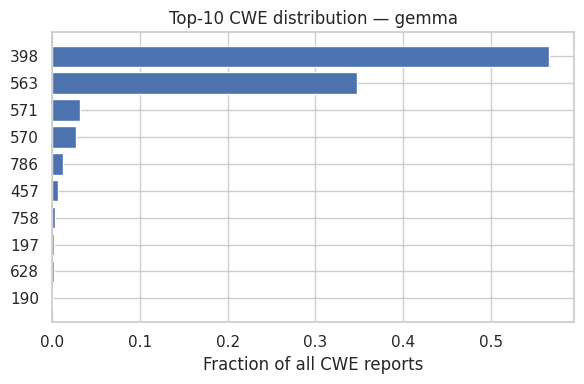

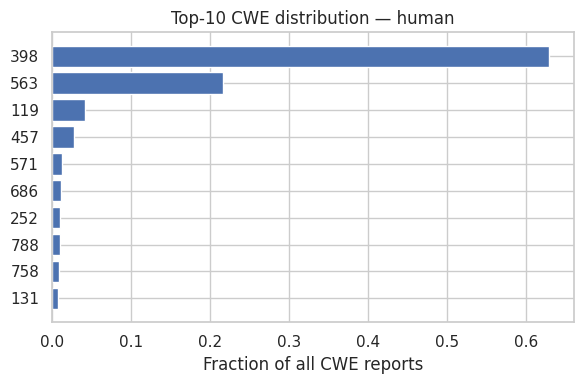

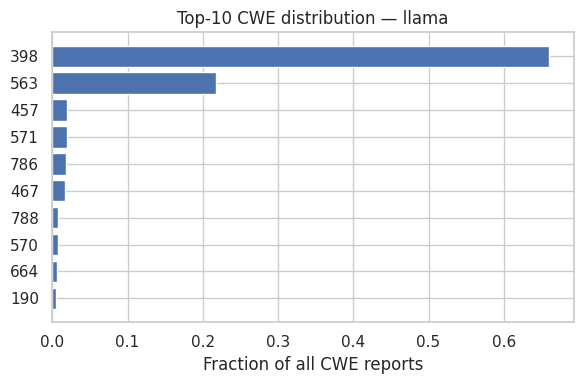

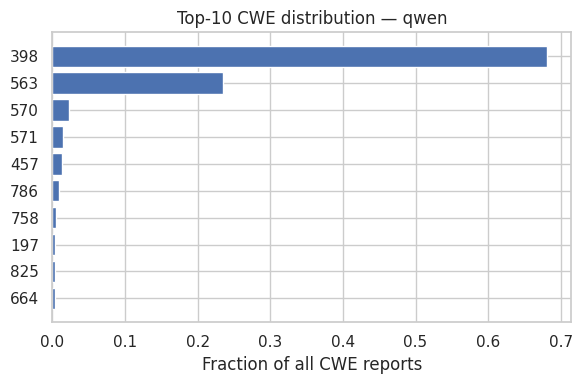

In [150]:
# scripts/plot_per_cwe_distribution.py
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../results/raw_csv/cppcheck_agg.csv")

# Normalize CWE label (e.g., "CWE-119")
df["cwe_id"] = df["cwe"].astype(str).str.extract(r"(\d+)")

# Drop rows without CWE mapping
df = df.dropna(subset=["cwe_id"])

# Count CWEs per model (global distribution)
cwe_counts = (
    df.groupby(["model", "cwe_id"])
      .size()
      .reset_index(name="count")
)

# Normalize per model
cwe_counts["fraction"] = (
    cwe_counts.groupby("model")["count"]
              .transform(lambda x: x / x.sum())
)


TOP_K = 10

for model, g in cwe_counts.groupby("model"):
    top = g.sort_values("count", ascending=False).head(TOP_K)

    plt.figure(figsize=(6,4))
    plt.barh(top["cwe_id"], top["fraction"])
    plt.xlabel("Fraction of all CWE reports")
    plt.title(f"Top-{TOP_K} CWE distribution — {model}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(f"../results/figures/cwe_type_dist_{model}.pdf")
    plt.show()
    plt.close()

In [151]:
# scripts/mitre_top25_program_prevalence.py
import pandas as pd
import re

MITRE_TOP25 = {
    20,22,59,73,77,78,79,89,94,119,
    120,125,190,200,269,287,295,306,
    352,362,400,416,476,787
}

df = pd.read_csv("../results/raw_csv/cppcheck_agg.csv")

def cwe_num(cwe):
    if pd.isna(cwe): return None
    m = re.search(r"\d+", str(cwe))
    return int(m.group()) if m else None

df["cwe_num"] = df["cwe"].apply(cwe_num)
df["is_top25"] = df["cwe_num"].apply(
    lambda x: x in MITRE_TOP25 if x is not None else False
)

# program-level indicator
prog = (
    df.groupby(["model","generation","program_key"])["is_top25"]
      .any()
      .reset_index(name="has_top25")
)

summary = (
    prog.groupby(["model","generation"])
        .agg(
            top25_prevalence=("has_top25","mean"),
            n_programs=("has_top25","count")
        )
        .reset_index()
)

summary.to_csv(
    "../results/tables/mitre_top25_program_prevalence.csv",
    index=False
)

print("Wrote mitre_top25_program_prevalence.csv")

summary

Wrote mitre_top25_program_prevalence.csv


,model,generation,top25_prevalence,n_programs
0,gemma,gen_1,0.000000,212
1,gemma,gen_2,0.004484,223
2,gemma,gen_3,0.004630,216
3,human,soln1,0.169960,253
4,human,soln2,0.180328,244
5,llama,gen_1,0.033816,207
6,llama,gen_2,0.025381,197
7,llama,gen_3,0.005000,200
8,qwen,gen_1,0.005025,199
9,qwen,gen_2,0.000000,214


In [154]:
# scripts/mitre_top25_counts_per_program.py
import pandas as pd
import re

MITRE_TOP25 = {
    20,22,59,73,77,78,79,89,94,119,
    120,125,190,200,269,287,295,306,
    352,362,400,416,476,787
}

df = pd.read_csv("../results/raw_csv/cppcheck_summary.csv")

def cwe_num(cwe):
    if pd.isna(cwe):
        return None
    m = re.search(r"\d+", str(cwe))
    return int(m.group()) if m else None

df["cwe_num"] = df["cwe"].apply(cwe_num)
df["is_top25"] = df["cwe_num"].apply(
    lambda x: x in MITRE_TOP25 if x is not None else False
)

# count Top-25 CWE instances per program
prog_counts = (
    df[df["is_top25"]]
    .groupby(["model","generation","program_key"])
    .size()
    .reset_index(name="top25_count")
)

# include programs with zero Top-25 CWEs
programs = (
    df.groupby(["model","generation","program_key"])
      .size()
      .reset_index()[["model","generation","program_key"]]
)

prog_counts = all_programs.merge(
    prog_counts,
    on=["model","generation","program_key"],
    how="left"
).fillna({"top25_count": 0})

prog_counts["top25_count"] = prog_counts["top25_count"].astype(int)

prog_counts.to_csv(
    "../results/tables/mitre_top25_counts_per_program.csv",
    index=False
)

prog_counts = prog_counts[prog_counts['top25_count']>0] 


# group by model and generation: count programs with ≥1 Top-25 CWE
summary = (
    prog_counts
    .groupby(["model", "generation"])
    .agg(
        n_programs_with_top25=("program_key", "nunique")
    )
    .reset_index()
)

print(summary)



KeyError: 'cwe'

In [155]:
vul = pd.read_csv("../results/raw_csv/cppcheck_agg.csv")

vul_flag = (
    vul.groupby(["model","generation","program_key"])
       .size()
       .reset_index(name="cwe_count")
)

vul_flag["has_cwe"] = True


df = programs.merge(
    vul_flag[["model","generation","program_key","has_cwe"]],
    on=["model","generation","program_key"],
    how="left"
)

df["has_cwe"] = df["has_cwe"].fillna(False)



KeyError: 'program_key'

In [ ]:
gen_stats = (
    df.groupby(["model","generation"])
      .agg(
          vulnerable_programs=("has_cwe","sum"),
          total_programs=("has_cwe","count")
      )
      .reset_index()
)

gen_stats["vuln_rate"] = (
    gen_stats["vulnerable_programs"] / gen_stats["total_programs"]
)

gen_stats

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=summary,
    x="generation",
    y="fraction",
    hue="model",
    palette='Set2'
)

plt.title("CWE in Generated Code Analyzed Coding Solutions")

ax.set_ylabel("Fraction of Programs with ≥1 CWE")
ax.set_xlabel("Generation")
ax.set_ylim(0, 1)

plt.legend(title="Model", fontsize='small', title_fontsize='small',)

plt.tight_layout()
plt.savefig("../results/figures/Baseline_CWE.pdf")
plt.show()

### CWE with tags Gemma 1

In [1]:
inst = (
    vul.groupby("program_key")
       .agg(
           has_cwe=("cwe", lambda x: x.notna().any()),
           cwe_list=("cwe", lambda x: set(x.dropna()))
       )
       .reset_index()
)

NameError: name 'vul' is not defined

In [ ]:
tags = pd.read_csv("../results/raw_csv/instruction_tags.csv")

tags["shard"] = tags["shard"].astype(int).map(lambda x: f"{x:05d}")


inst["shard"] = inst["program_key"] % 3
inst["shard"] = inst["shard"].map(lambda x: f"{x:05d}")

df = inst.merge(tags, on=["program_key","shard"], how="left")
df = df.assign(tag=df["tags"].str.split("|")).explode("tags")

In [ ]:
df_cwe = df.explode("cwe_list").dropna(subset=["cwe_list"])

In [ ]:
tag_cwe_counts = (
    df_cwe.groupby(["tags", "cwe_list"])
          .size()
          .reset_index(name="count")
          .sort_values(["tags", "count"], ascending=[True, False])
)

In [ ]:
tag_cwe_counts = tag_cwe_counts[tag_cwe_counts["count"] >= 5]
tag_cwe_counts

# Summary Statistics & Bootstrap Analysis

## T1: Dataset Summary

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

master = pd.read_csv("../results/raw_csv/master_analysis.csv")

summary = (
    master.groupby(["model", "generation"])
          .agg(
              n_samples=("sample_id", "count"),
              compiled=("compiled", "sum"),
              has_tests=("has_tests", "sum"),
          )
          .reset_index()
)

summary["compile_rate"] = summary["compiled"] / summary["n_samples"]

summary.to_csv("../results/tables/dataset_summary.csv", index=False)
summary

,model,generation,n_samples,compiled,has_tests,compile_rate
0,gemma,gen_1,745,668,402,0.896644
1,gemma,gen_2,740,667,400,0.901351
2,gemma,gen_3,753,683,404,0.907039
3,human,soln1,851,831,494,0.976498
4,human,soln2,844,834,500,0.988152
5,llama,gen_1,849,763,468,0.898704
6,llama,gen_2,800,736,438,0.920000
7,llama,gen_3,847,773,476,0.912633
8,qwen,gen_1,850,788,479,0.927059
9,qwen,gen_2,823,745,451,0.905225


## T2: Pass Rate by Model with Bootstrap CI

In [3]:
bootstrap_ci = pd.read_csv("../results/raw_csv/bootstrap_ci_results.csv")

pass_rates = bootstrap_ci[bootstrap_ci["metric"].isin(["full_pass_rate", "mean_pass_rate"])]
pass_rates = pass_rates[["metric", "model", "n_samples", "point_estimate", "ci_lower", "ci_upper"]]

pass_rates.to_csv("../results/tables/pass_rate_bootstrap_ci.csv", index=False)
pass_rates

,metric,model,n_samples,point_estimate,ci_lower,ci_upper
0,full_pass_rate,human,994,0.752515,0.725352,0.778672
1,mean_pass_rate,human,994,0.829680,0.808264,0.850150
2,full_pass_rate,qwen,1379,0.149384,0.131255,0.168238
3,mean_pass_rate,qwen,1379,0.376586,0.357630,0.395527
4,full_pass_rate,gemma,1206,0.223051,0.199834,0.246269
5,mean_pass_rate,gemma,1206,0.467500,0.445773,0.488684
6,full_pass_rate,llama,1382,0.209117,0.188133,0.231548
7,mean_pass_rate,llama,1382,0.425108,0.405210,0.445756


## T3: Human vs AI Pass Rate Differences

In [4]:
diff_metrics = bootstrap_ci[bootstrap_ci["metric"].str.contains("diff_human")]
diff_table = diff_metrics[["metric", "model", "point_estimate", "ci_lower", "ci_upper", "p_value", "significant_95"]]

diff_table.to_csv("../results/tables/human_vs_ai_differences.csv", index=False)
diff_table

,metric,model,point_estimate,ci_lower,ci_upper,p_value,significant_95
8,full_pass_diff_human_minus_ai,human - qwen,0.603131,0.570636,0.636215,0.0,True
9,mean_rate_diff_human_minus_ai,human - qwen,0.453095,0.425463,0.481679,0.0,True
10,full_pass_diff_human_minus_ai,human - gemma,0.529464,0.493301,0.564633,0.0,True
11,mean_rate_diff_human_minus_ai,human - gemma,0.362180,0.331571,0.392145,0.0,True
12,full_pass_diff_human_minus_ai,human - llama,0.543398,0.508892,0.578397,0.0,True
13,mean_rate_diff_human_minus_ai,human - llama,0.404572,0.374920,0.433721,0.0,True


## F1: Pass Rate Bar Chart with Error Bars

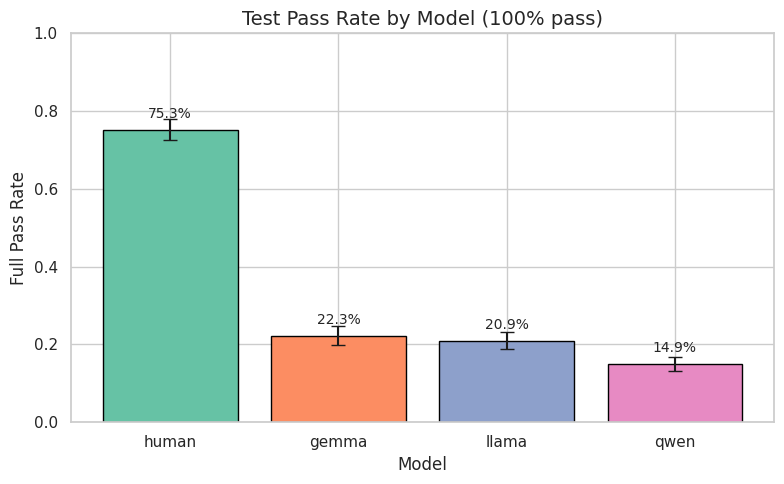

In [5]:
full_pass = bootstrap_ci[bootstrap_ci["metric"] == "full_pass_rate"].copy()
full_pass["error_low"] = full_pass["point_estimate"] - full_pass["ci_lower"]
full_pass["error_high"] = full_pass["ci_upper"] - full_pass["point_estimate"]

model_order = ["human", "gemma", "llama", "qwen"]
full_pass["model"] = pd.Categorical(full_pass["model"], categories=model_order, ordered=True)
full_pass = full_pass.sort_values("model")

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette("Set2", n_colors=4)

bars = ax.bar(
    full_pass["model"],
    full_pass["point_estimate"],
    yerr=[full_pass["error_low"], full_pass["error_high"]],
    capsize=5,
    color=colors,
    edgecolor="black"
)

ax.set_ylabel("Full Pass Rate", fontsize=12)
ax.set_xlabel("Model", fontsize=12)
ax.set_title("Test Pass Rate by Model (100% pass)", fontsize=14)
ax.set_ylim(0, 1)

for bar, val in zip(bars, full_pass["point_estimate"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f"{val:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../results/figures/pass_rate_by_model.pdf")
plt.savefig("../results/figures/pass_rate_by_model.png", dpi=150)
plt.show()

## T4 & T5: CWE Summary (Compiled & Passing)

In [6]:
cwe_compiled = bootstrap_ci[bootstrap_ci["metric"] == "mean_cwe_count_compiled"]
cwe_passing = bootstrap_ci[bootstrap_ci["metric"] == "mean_cwe_count_passing"]

cwe_summary = pd.concat([
    cwe_compiled.assign(subset="compiled"),
    cwe_passing.assign(subset="passing")
])

cwe_summary = cwe_summary[["subset", "model", "n_samples", "point_estimate", "ci_lower", "ci_upper"]]
cwe_summary.to_csv("../results/tables/cwe_summary_by_subset.csv", index=False)
cwe_summary

,subset,model,n_samples,point_estimate,ci_lower,ci_upper
14,compiled,human,1665,1.365165,1.230030,1.508724
16,compiled,qwen,2290,0.696943,0.639301,0.757205
18,compiled,gemma,2018,1.059465,0.972250,1.148674
20,compiled,llama,2272,0.604313,0.553257,0.656690
28,passing,human,748,1.208556,1.038770,1.394385
29,passing,qwen,206,0.529126,0.412621,0.665049
30,passing,gemma,269,0.579926,0.472119,0.695167
31,passing,llama,289,0.304498,0.238754,0.373702


## F2: CWE per File (Passing vs Failing)

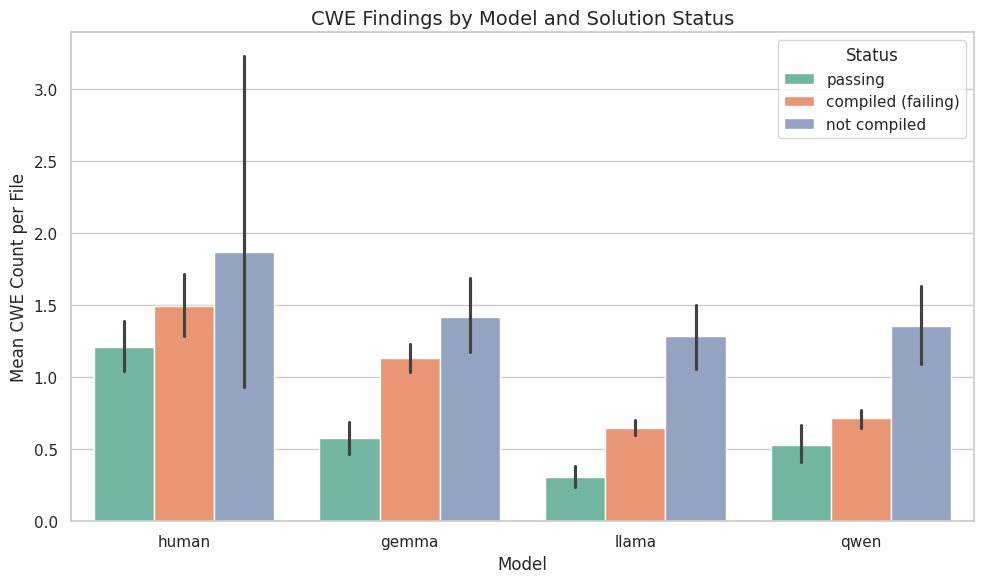

In [7]:
master = pd.read_csv("../results/raw_csv/master_analysis.csv")
detailed = pd.read_csv("../results/raw_csv/cppcheck_detailed.csv")

detailed_cwe = detailed[detailed["cwe"].notna()].copy()
detailed_cwe["sample_id"] = detailed_cwe["sample_id"].apply(
    lambda x: x if x.endswith(".cpp") else x + ".cpp"
)

cwe_counts = detailed_cwe.groupby("sample_id").size().reset_index(name="cwe_count")
master_cwe = master.merge(cwe_counts, on="sample_id", how="left")
master_cwe["cwe_count"] = master_cwe["cwe_count"].fillna(0)

master_cwe["status"] = "not compiled"
master_cwe.loc[master_cwe["compiled"] == True, "status"] = "compiled (failing)"
master_cwe.loc[master_cwe["pass_rate"] == 1.0, "status"] = "passing"

status_order = ["passing", "compiled (failing)", "not compiled"]
master_cwe["status"] = pd.Categorical(master_cwe["status"], categories=status_order, ordered=True)

model_order = ["human", "gemma", "llama", "qwen"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=master_cwe,
    x="model",
    y="cwe_count",
    hue="status",
    order=model_order,
    palette="Set2",
    ax=ax,
    errorbar="ci"
)

ax.set_ylabel("Mean CWE Count per File", fontsize=12)
ax.set_xlabel("Model", fontsize=12)
ax.set_title("CWE Findings by Model and Solution Status", fontsize=14)
ax.legend(title="Status")

plt.tight_layout()
plt.savefig("../results/figures/cwe_by_status.pdf")
plt.savefig("../results/figures/cwe_by_status.png", dpi=150)
plt.show()

## T6: Top CWEs by Model (Passing Only)

In [8]:
passing_ids = set(master[master["pass_rate"] == 1.0]["sample_id"])

detailed_cwe["cwe"] = detailed_cwe["cwe"].astype(int)
df_pass = detailed_cwe[detailed_cwe["sample_id"].isin(passing_ids)]

top_cwes_list = []
for model in ["human", "gemma", "llama", "qwen"]:
    model_df = df_pass[df_pass["model"] == model]
    top5 = model_df["cwe"].value_counts().head(5).reset_index()
    top5.columns = ["cwe", "count"]
    top5["model"] = model
    top5["rank"] = range(1, len(top5) + 1)
    top_cwes_list.append(top5)

top_cwes = pd.concat(top_cwes_list)
top_cwes["cwe_label"] = "CWE-" + top_cwes["cwe"].astype(str)

top_cwes_pivot = top_cwes.pivot(index="rank", columns="model", values="cwe_label")
top_cwes_pivot = top_cwes_pivot[["human", "gemma", "llama", "qwen"]]

top_cwes_pivot.to_csv("../results/tables/top_cwes_by_model_passing.csv")
top_cwes_pivot

model,human,gemma,llama,qwen
rank,,,,
1,CWE-398,CWE-398,CWE-398,CWE-398
2,CWE-563,CWE-563,CWE-563,CWE-563
3,CWE-119,CWE-786,CWE-571,CWE-570
4,CWE-457,CWE-457,CWE-786,NaN
5,CWE-571,NaN,CWE-758,NaN


## F3: Top CWE Heatmap (Compiled)

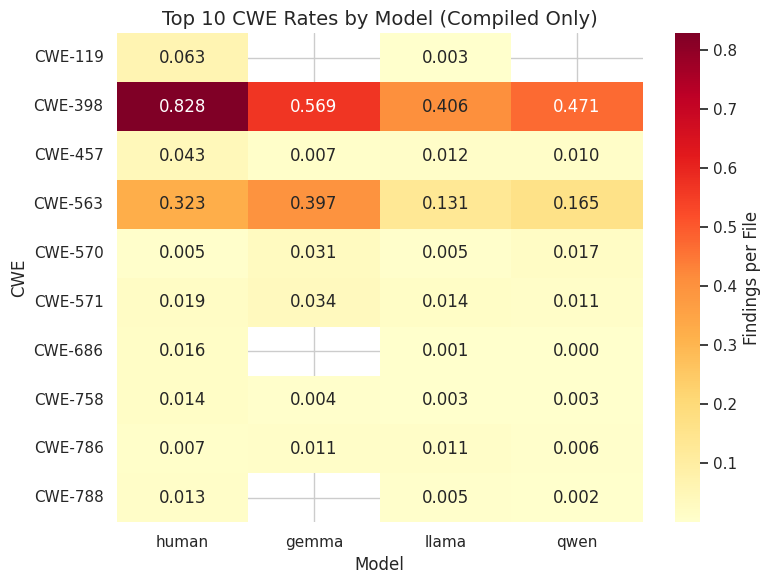

In [9]:
compiled_ids = set(master[master["compiled"] == True]["sample_id"])
df_compiled = detailed_cwe[detailed_cwe["sample_id"].isin(compiled_ids)]

top10_cwes = df_compiled["cwe"].value_counts().head(10).index.tolist()

cwe_model_counts = (
    df_compiled[df_compiled["cwe"].isin(top10_cwes)]
    .groupby(["model", "cwe"])
    .size()
    .reset_index(name="count")
)

n_files_per_model = master[master["compiled"] == True].groupby("model").size()
cwe_model_counts["rate"] = cwe_model_counts.apply(
    lambda row: row["count"] / n_files_per_model[row["model"]], axis=1
)

heatmap_data = cwe_model_counts.pivot(index="cwe", columns="model", values="rate")
heatmap_data = heatmap_data[["human", "gemma", "llama", "qwen"]]
heatmap_data.index = "CWE-" + heatmap_data.index.astype(str)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Findings per File"}
)

ax.set_title("Top 10 CWE Rates by Model (Compiled Only)", fontsize=14)
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("CWE", fontsize=12)

plt.tight_layout()
plt.savefig("../results/figures/cwe_heatmap.pdf")
plt.savefig("../results/figures/cwe_heatmap.png", dpi=150)
plt.show()

## T7: CWE Stability Across Generations

In [10]:
stability = pd.read_csv("../results/raw_csv/cwe_stability.csv")

stability_display = stability[[
    "model", "gen1", "gen2", 
    "jaccard_similarity", "spearman_correlation", "bhattacharyya_distance"
]].round(3)

stability_display.to_csv("../results/tables/cwe_stability.csv", index=False)
stability_display

,model,gen1,gen2,jaccard_similarity,spearman_correlation,bhattacharyya_distance
0,human,soln1,soln2,0.760,0.808,0.008
1,qwen,gen_1,gen_2,0.474,0.640,0.021
2,qwen,gen_1,gen_3,0.667,0.874,0.011
3,qwen,gen_2,gen_3,0.643,0.813,0.018
4,gemma,gen_1,gen_2,0.818,0.909,0.011
5,gemma,gen_1,gen_3,0.818,0.928,0.006
6,gemma,gen_2,gen_3,0.818,0.909,0.004
7,llama,gen_1,gen_2,0.667,0.785,0.015
8,llama,gen_1,gen_3,0.688,0.771,0.017
9,llama,gen_2,gen_3,0.706,0.760,0.020


## F5: CWE Stability Bar Chart

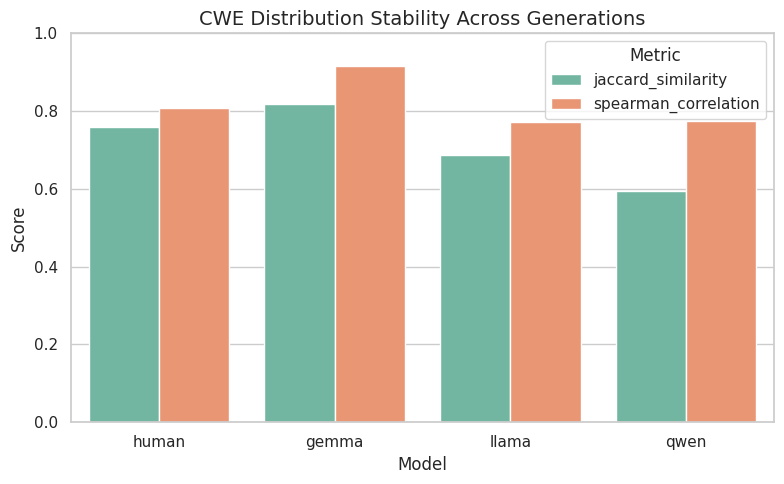

In [31]:
stability_avg = (
    stability.groupby("model")[["jaccard_similarity", "spearman_correlation"]]
             .mean()
             .reset_index()
)

stability_melt = stability_avg.melt(
    id_vars="model",
    value_vars=["jaccard_similarity", "spearman_correlation"],
    var_name="metric",
    value_name="value"
)

model_order = ["human", "gemma", "llama", "qwen"]
stability_melt["model"] = pd.Categorical(stability_melt["model"], categories=model_order, ordered=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=stability_melt,
    x="model",
    y="value",
    hue="metric",
    palette="Set2",
    ax=ax
)

ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("Model", fontsize=12)
ax.set_title("CWE Distribution Stability Across Generations", fontsize=14)
ax.set_ylim(0, 1)
ax.legend(title="Metric")

plt.tight_layout()
plt.savefig("../results/figures/cwe_stability.pdf")
plt.savefig("../results/figures/cwe_stability.png", dpi=150)
plt.show()

## F6: Bootstrap CI Forest Plot (Human vs AI)

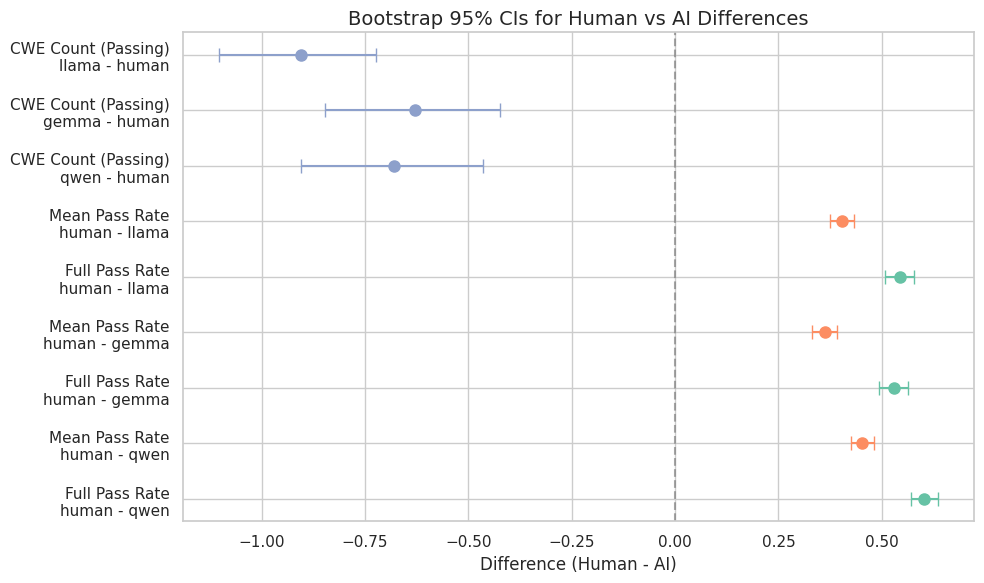

In [12]:
diff_data = bootstrap_ci[
    bootstrap_ci["metric"].isin([
        "full_pass_diff_human_minus_ai",
        "mean_rate_diff_human_minus_ai",
        "cwe_count_diff_passing"
    ])
].copy()

diff_data["label"] = diff_data["metric"].map({
    "full_pass_diff_human_minus_ai": "Full Pass Rate",
    "mean_rate_diff_human_minus_ai": "Mean Pass Rate",
    "cwe_count_diff_passing": "CWE Count (Passing)"
}) + "\n" + diff_data["model"]

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = range(len(diff_data))
colors = sns.color_palette("Set2", n_colors=3)
color_map = {
    "Full Pass Rate": colors[0],
    "Mean Pass Rate": colors[1],
    "CWE Count (Passing)": colors[2]
}

for i, (_, row) in enumerate(diff_data.iterrows()):
    metric_type = row["label"].split("\n")[0]
    ax.errorbar(
        row["point_estimate"],
        i,
        xerr=[[row["point_estimate"] - row["ci_lower"]], [row["ci_upper"] - row["point_estimate"]]],
        fmt="o",
        color=color_map[metric_type],
        capsize=5,
        markersize=8
    )

ax.axvline(x=0, color="gray", linestyle="--", alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(diff_data["label"])
ax.set_xlabel("Difference (Human - AI)", fontsize=12)
ax.set_title("Bootstrap 95% CIs for Human vs AI Differences", fontsize=14)

plt.tight_layout()
plt.savefig("../results/figures/forest_plot_differences.pdf")
plt.savefig("../results/figures/forest_plot_differences.png", dpi=150)
plt.show()

# Clang-Tidy Analysis with Test Pass Rate

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

master = pd.read_csv("../results/raw_csv/master_analysis.csv")
ct_detailed = pd.read_csv("../results/raw_csv/clang_tidy_detailed.csv")
ct_summary = pd.read_csv("../results/raw_csv/clang_tidy_summary.csv")

# Align file column with master sample_id (detailed has no .cpp suffix)
ct_detailed["sample_id"] = ct_detailed["file"].apply(
    lambda x: x if x.endswith(".cpp") else x + ".cpp"
)
ct_summary["sample_id"] = ct_summary["file"].apply(
    lambda x: x if x.endswith(".cpp") else x + ".cpp"
)

print(f"Master rows: {len(master)}")
print(f"Clang-tidy detailed rows: {len(ct_detailed)}")
print(f"Clang-tidy summary rows: {len(ct_summary)}")
print(f"Unique diagnostics: {ct_detailed['diagnostic_name'].nunique()}")
print(f"Categories: {ct_detailed['category'].unique().tolist()}")

Master rows: 8918
Clang-tidy detailed rows: 56311
Clang-tidy summary rows: 8918
Unique diagnostics: 117
Categories: ['modernize', 'compiler-warning', 'bugprone', 'analyzer', 'performance']


## CT-F1: Clang-Tidy Diagnostics by File Status (Passing vs Failing)

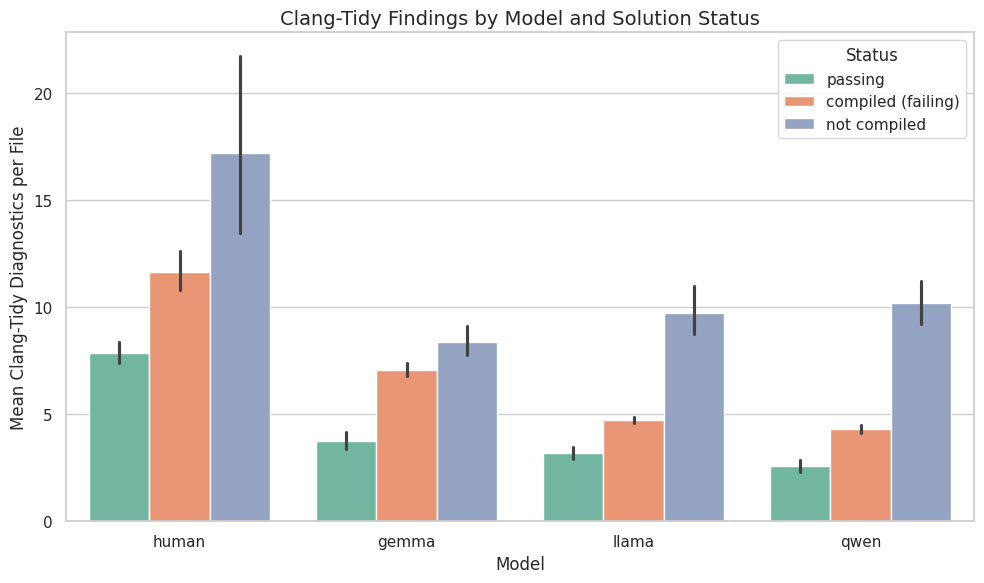

In [14]:
# Count clang-tidy diagnostics per sample_id
ct_counts = ct_detailed.groupby("sample_id").size().reset_index(name="ct_count")
master_ct = master.merge(ct_counts, on="sample_id", how="left")
master_ct["ct_count"] = master_ct["ct_count"].fillna(0)

# Classify file status
master_ct["status"] = "not compiled"
master_ct.loc[master_ct["compiled"] == True, "status"] = "compiled (failing)"
master_ct.loc[master_ct["pass_rate"] == 1.0, "status"] = "passing"

status_order = ["passing", "compiled (failing)", "not compiled"]
master_ct["status"] = pd.Categorical(master_ct["status"], categories=status_order, ordered=True)

model_order = ["human", "gemma", "llama", "qwen"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=master_ct,
    x="model",
    y="ct_count",
    hue="status",
    order=model_order,
    palette="Set2",
    ax=ax,
    errorbar="ci"
)

ax.set_ylabel("Mean Clang-Tidy Diagnostics per File", fontsize=12)
ax.set_xlabel("Model", fontsize=12)
ax.set_title("Clang-Tidy Findings by Model and Solution Status", fontsize=14)
ax.legend(title="Status")

plt.tight_layout()
plt.savefig("../results/figures/clang_tidy_by_status.pdf")
plt.savefig("../results/figures/clang_tidy_by_status.png", dpi=150)
plt.show()

## CT-F2: Security Diagnostics (bugprone + analyzer) by File Status

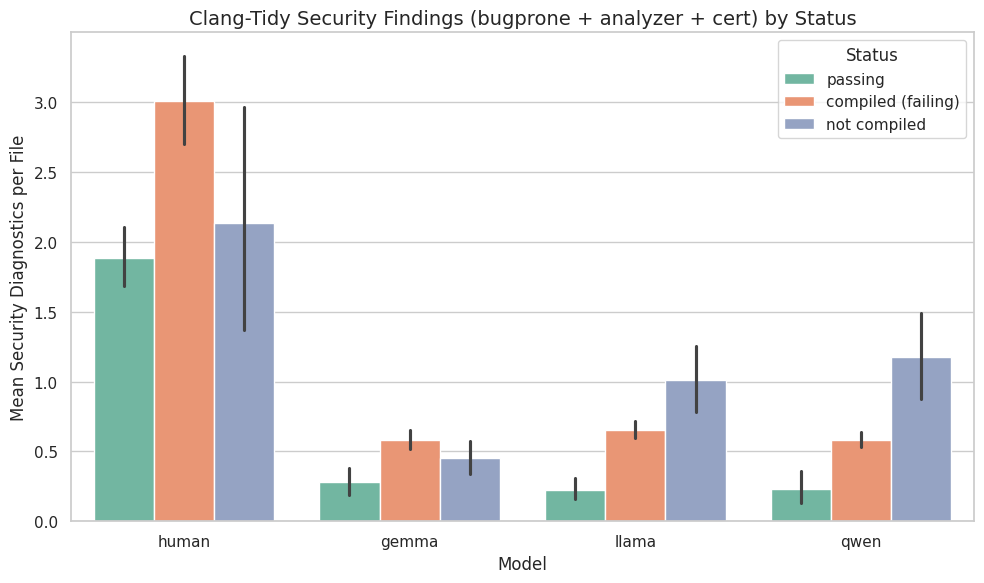

In [15]:
# Security-relevant categories: bugprone, analyzer, cert
security_cats = ["bugprone", "analyzer", "cert"]
ct_security = ct_detailed[ct_detailed["category"].isin(security_cats)]

sec_counts = ct_security.groupby("sample_id").size().reset_index(name="security_count")
master_sec = master.merge(sec_counts, on="sample_id", how="left")
master_sec["security_count"] = master_sec["security_count"].fillna(0)

master_sec["status"] = "not compiled"
master_sec.loc[master_sec["compiled"] == True, "status"] = "compiled (failing)"
master_sec.loc[master_sec["pass_rate"] == 1.0, "status"] = "passing"

status_order = ["passing", "compiled (failing)", "not compiled"]
master_sec["status"] = pd.Categorical(master_sec["status"], categories=status_order, ordered=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=master_sec,
    x="model",
    y="security_count",
    hue="status",
    order=model_order,
    palette="Set2",
    ax=ax,
    errorbar="ci"
)

ax.set_ylabel("Mean Security Diagnostics per File", fontsize=12)
ax.set_xlabel("Model", fontsize=12)
ax.set_title("Clang-Tidy Security Findings (bugprone + analyzer + cert) by Status", fontsize=14)
ax.legend(title="Status")

plt.tight_layout()
plt.savefig("../results/figures/clang_tidy_security_by_status.pdf")
plt.savefig("../results/figures/clang_tidy_security_by_status.png", dpi=150)
plt.show()

## CT-T1: Top 10 Diagnostics by Model (Passing Only)

In [16]:
passing_ids = set(master[master["pass_rate"] == 1.0]["sample_id"])
ct_pass = ct_detailed[ct_detailed["sample_id"].isin(passing_ids)]

top_diag_list = []
for model in model_order:
    model_df = ct_pass[ct_pass["model"] == model]
    top10 = model_df["diagnostic_name"].value_counts().head(10).reset_index()
    top10.columns = ["diagnostic", "count"]
    top10["model"] = model
    top10["rank"] = range(1, len(top10) + 1)
    top_diag_list.append(top10)

top_diags = pd.concat(top_diag_list)
top_diags_pivot = top_diags.pivot(index="rank", columns="model", values="diagnostic")
top_diags_pivot = top_diags_pivot[model_order]

top_diags_pivot.to_csv("../results/tables/top_clang_tidy_by_model_passing.csv")
top_diags_pivot

model,human,gemma,llama,qwen
rank,,,,
1,modernize-use-trailing-return-type,performance-avoid-endl,performance-avoid-endl,modernize-use-trailing-return-type
2,modernize-avoid-c-arrays,modernize-use-trailing-return-type,modernize-use-trailing-return-type,performance-avoid-endl
3,bugprone-narrowing-conversions,bugprone-branch-clone,modernize-avoid-c-arrays,modernize-use-nullptr
4,performance-avoid-endl,bugprone-narrowing-conversions,bugprone-narrowing-conversions,bugprone-narrowing-conversions
5,clang-analyzer-security.ArrayBound,modernize-use-emplace,modernize-use-nullptr,modernize-avoid-c-arrays
6,modernize-use-bool-literals,clang-analyzer-deadcode.DeadStores,modernize-use-using,modernize-use-emplace
7,modernize-use-nullptr,modernize-loop-convert,clang-diagnostic-vla-cxx-extension,bugprone-implicit-widening-of-multiplication-r...
8,bugprone-easily-swappable-parameters,modernize-avoid-c-arrays,modernize-use-emplace,clang-analyzer-deadcode.DeadStores
9,modernize-loop-convert,bugprone-implicit-widening-of-multiplication-r...,bugprone-easily-swappable-parameters,performance-inefficient-vector-operation


## CT-F3: Clang-Tidy Category Heatmap (Compiled Only)

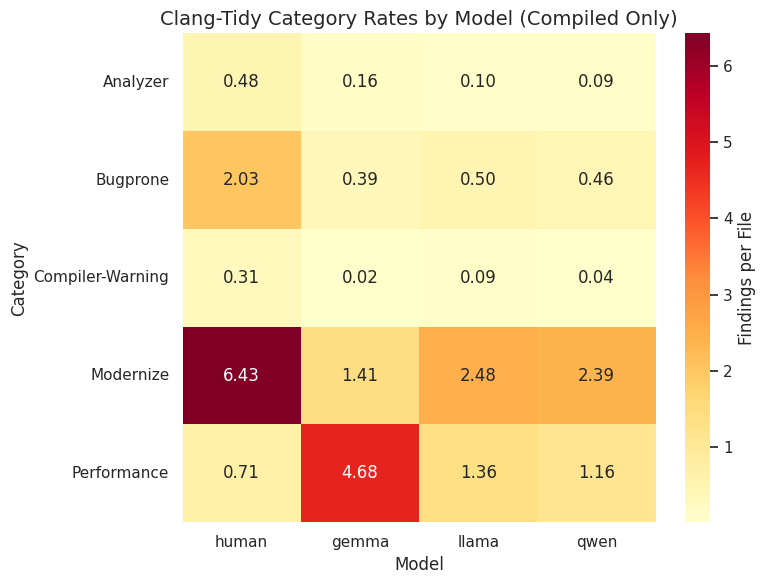

In [17]:
compiled_ids = set(master[master["compiled"] == True]["sample_id"])
ct_compiled = ct_detailed[ct_detailed["sample_id"].isin(compiled_ids)]

cat_model_counts = (
    ct_compiled.groupby(["model", "category"])
    .size()
    .reset_index(name="count")
)

n_files_per_model = master[master["compiled"] == True].groupby("model").size()
cat_model_counts["rate"] = cat_model_counts.apply(
    lambda row: row["count"] / n_files_per_model[row["model"]], axis=1
)

heatmap_data = cat_model_counts.pivot(index="category", columns="model", values="rate").fillna(0)
heatmap_data = heatmap_data[model_order]

# Capitalize category names for display
heatmap_data.index = heatmap_data.index.str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Findings per File"}
)

ax.set_title("Clang-Tidy Category Rates by Model (Compiled Only)", fontsize=14)
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Category", fontsize=12)

plt.tight_layout()
plt.savefig("../results/figures/clang_tidy_heatmap.pdf")
plt.savefig("../results/figures/clang_tidy_heatmap.png", dpi=150)
plt.show()

## CT-F4: Total Diagnostics by Model and Generation

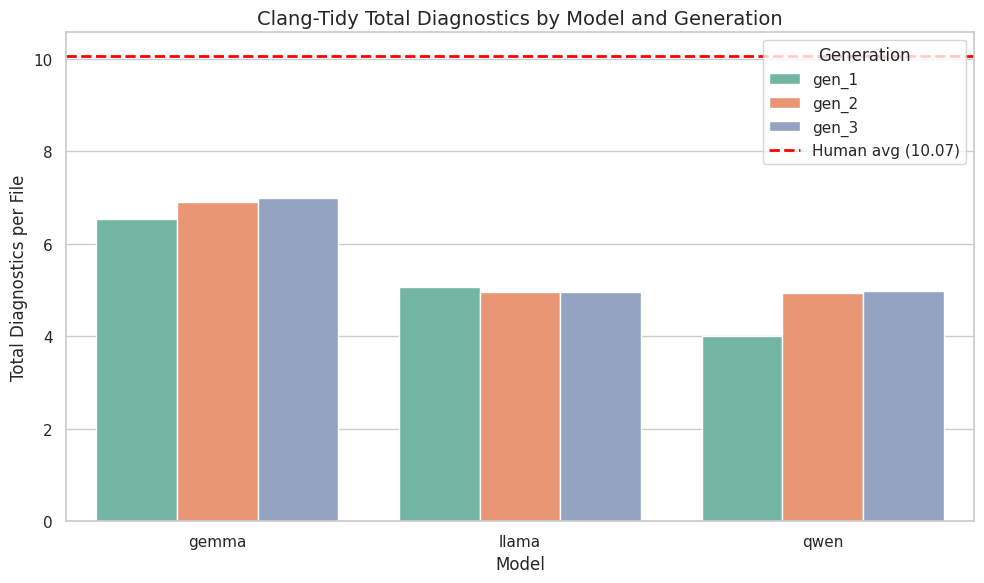

generation,gen_1,gen_2,gen_3
model,,,
gemma,6.542,6.912,6.997
llama,5.069,4.951,4.960
qwen,4.001,4.928,4.971


In [18]:
# Per-file totals from master (already merged)
ct_by_gen = (
    master[master["model"] != "human"]
    .groupby(["model", "generation"])
    .agg(total_per_file=("clang_total", "mean"), n_files=("sample_id", "count"))
    .reset_index()
)

human_avg = master[master["model"] == "human"]["clang_total"].mean()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=ct_by_gen,
    x="model",
    y="total_per_file",
    hue="generation",
    palette="Set2",
    ax=ax
)

ax.axhline(y=human_avg, color="red", linestyle="--", linewidth=2,
           label=f"Human avg ({human_avg:.2f})")

ax.set_ylabel("Total Diagnostics per File", fontsize=12)
ax.set_xlabel("Model", fontsize=12)
ax.set_title("Clang-Tidy Total Diagnostics by Model and Generation", fontsize=14)
ax.legend(title="Generation")

plt.tight_layout()
plt.savefig("../results/figures/clang_tidy_total_by_model_gen.pdf")
plt.savefig("../results/figures/clang_tidy_total_by_model_gen.png", dpi=150)
plt.show()

ct_by_gen_table = ct_by_gen.pivot(index="model", columns="generation", values="total_per_file").round(3)
ct_by_gen_table.to_csv("../results/tables/clang_tidy_total_pivot.csv")
ct_by_gen_table

## CT-F5: Security Diagnostics by Model and Generation

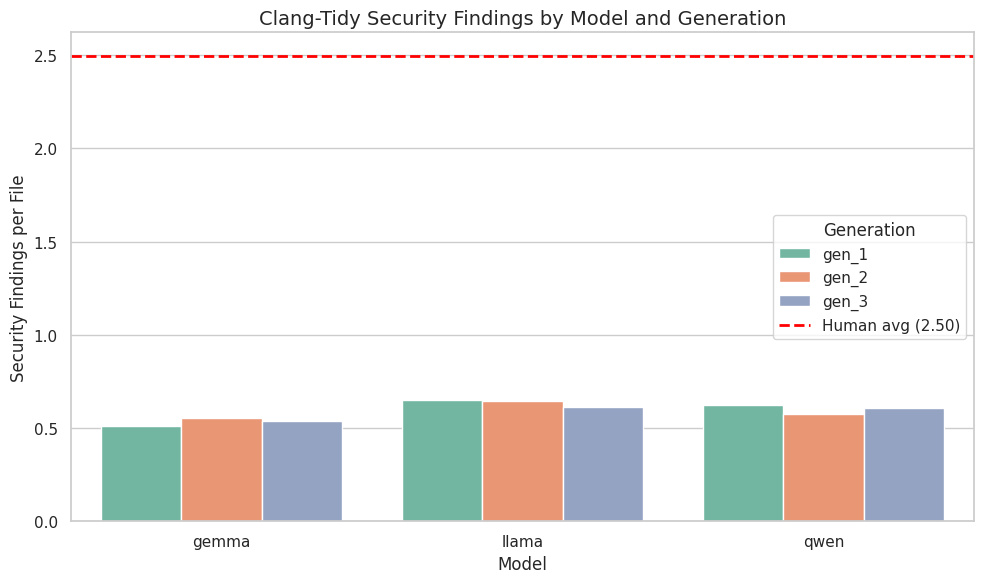

generation,gen_1,gen_2,gen_3
model,,,
gemma,0.511,0.554,0.537
llama,0.649,0.646,0.615
qwen,0.625,0.576,0.605


In [19]:
# Security = bugprone + analyzer (+ cert if present) from master columns
master["clang_security"] = master["clang_bugprone"].fillna(0) + master["clang_analyzer"].fillna(0)

sec_by_gen = (
    master[master["model"] != "human"]
    .groupby(["model", "generation"])
    .agg(security_per_file=("clang_security", "mean"), n_files=("sample_id", "count"))
    .reset_index()
)

human_sec_avg = master[master["model"] == "human"]["clang_security"].mean()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=sec_by_gen,
    x="model",
    y="security_per_file",
    hue="generation",
    palette="Set2",
    ax=ax
)

ax.axhline(y=human_sec_avg, color="red", linestyle="--", linewidth=2,
           label=f"Human avg ({human_sec_avg:.2f})")

ax.set_ylabel("Security Findings per File", fontsize=12)
ax.set_xlabel("Model", fontsize=12)
ax.set_title("Clang-Tidy Security Findings by Model and Generation", fontsize=14)
ax.legend(title="Generation")

plt.tight_layout()
plt.savefig("../results/figures/clang_tidy_security_by_model_gen.pdf")
plt.savefig("../results/figures/clang_tidy_security_by_model_gen.png", dpi=150)
plt.show()

sec_pivot = sec_by_gen.pivot(index="model", columns="generation", values="security_per_file").round(3)
sec_pivot.to_csv("../results/tables/clang_tidy_security_pivot.csv")
sec_pivot

## CT-T2: Clang-Tidy Pass/Fail Comparison

In [20]:
# Compare diagnostics per file between passing and failing solutions
master_tested = master[master["has_tests"] == True].copy()
master_tested["clang_security"] = master_tested["clang_bugprone"].fillna(0) + master_tested["clang_analyzer"].fillna(0)
master_tested["test_status"] = master_tested["pass_rate"].apply(
    lambda x: "passing" if x == 1.0 else "failing"
)

comparison_rows = []
for model in model_order:
    for status in ["passing", "failing"]:
        subset = master_tested[(master_tested["model"] == model) & (master_tested["test_status"] == status)]
        comparison_rows.append({
            "Model": model,
            "Status": status,
            "Security/file": round(subset["clang_security"].mean(), 3),
            "Total/file": round(subset["clang_total"].mean(), 3),
            "Bugprone/file": round(subset["clang_bugprone"].fillna(0).mean(), 3),
            "Analyzer/file": round(subset["clang_analyzer"].fillna(0).mean(), 3),
            "n_files": len(subset)
        })

ct_comparison = pd.DataFrame(comparison_rows)
ct_comparison.to_csv("../results/tables/clang_tidy_pass_fail_comparison.csv", index=False)
ct_comparison

,Model,Status,Security/file,Total/file,Bugprone/file,Analyzer/file,n_files
0,human,passing,1.888,7.846,1.344,0.544,748
1,human,failing,2.272,10.768,1.728,0.545,246
2,gemma,passing,0.279,3.751,0.219,0.059,269
3,gemma,failing,0.542,7.480,0.406,0.137,937
4,llama,passing,0.225,3.180,0.215,0.010,289
5,llama,failing,0.665,4.791,0.543,0.123,1093
6,qwen,passing,0.233,2.587,0.189,0.044,206
7,qwen,failing,0.625,4.342,0.530,0.095,1173


## CT-T3: Clang-Tidy Stability Across Generations

In [21]:
from scipy.stats import spearmanr

def compute_stability(ct_detailed_df, master_df):
    """Compute diagnostic type stability (Jaccard, Spearman) across generation pairs."""
    ct_with_status = ct_detailed_df.merge(
        master_df[["sample_id", "model", "generation", "compiled"]],
        on="sample_id", how="inner", suffixes=("", "_master")
    )
    ct_compiled = ct_with_status[ct_with_status["compiled"] == True]
    
    rows = []
    for model in ["gemma", "llama", "qwen"]:
        gens = sorted(ct_compiled[ct_compiled["model"] == model]["generation"].unique())
        for i in range(len(gens)):
            for j in range(i + 1, len(gens)):
                g1, g2 = gens[i], gens[j]
                d1 = ct_compiled[(ct_compiled["model"] == model) & (ct_compiled["generation"] == g1)]
                d2 = ct_compiled[(ct_compiled["model"] == model) & (ct_compiled["generation"] == g2)]
                
                types1 = set(d1["diagnostic_name"].unique())
                types2 = set(d2["diagnostic_name"].unique())
                
                jaccard = len(types1 & types2) / len(types1 | types2) if types1 | types2 else 0
                
                all_types = types1 | types2
                counts1 = d1["diagnostic_name"].value_counts()
                counts2 = d2["diagnostic_name"].value_counts()
                v1 = [counts1.get(t, 0) for t in all_types]
                v2 = [counts2.get(t, 0) for t in all_types]
                spearman = spearmanr(v1, v2).correlation if len(all_types) > 1 else 0
                
                rows.append({
                    "model": model, "gen1": g1, "gen2": g2,
                    "jaccard_similarity": round(jaccard, 4),
                    "spearman_correlation": round(spearman, 4),
                    "types_gen1": len(types1), "types_gen2": len(types2)
                })
    
    # Human: soln1 vs soln2
    for model_name, gen_col in [("human", "generation")]:
        d = ct_compiled[ct_compiled["model"] == model_name]
        gens = sorted(d[gen_col].unique())
        if len(gens) >= 2:
            d1 = d[d[gen_col] == gens[0]]
            d2 = d[d[gen_col] == gens[1]]
            types1 = set(d1["diagnostic_name"].unique())
            types2 = set(d2["diagnostic_name"].unique())
            jaccard = len(types1 & types2) / len(types1 | types2) if types1 | types2 else 0
            all_types = types1 | types2
            counts1 = d1["diagnostic_name"].value_counts()
            counts2 = d2["diagnostic_name"].value_counts()
            v1 = [counts1.get(t, 0) for t in all_types]
            v2 = [counts2.get(t, 0) for t in all_types]
            spearman = spearmanr(v1, v2).correlation if len(all_types) > 1 else 0
            rows.append({
                "model": "human", "gen1": gens[0], "gen2": gens[1],
                "jaccard_similarity": round(jaccard, 4),
                "spearman_correlation": round(spearman, 4),
                "types_gen1": len(types1), "types_gen2": len(types2)
            })
    
    return pd.DataFrame(rows)

# Use generation column from master for consistency
ct_detailed_with_gen = ct_detailed.merge(
    master[["sample_id", "generation", "compiled"]],
    on="sample_id", how="inner"
)

ct_stability = compute_stability(ct_detailed, master)
ct_stability.to_csv("../results/tables/clang_tidy_stability.csv", index=False)
ct_stability

,model,gen1,gen2,jaccard_similarity,spearman_correlation,types_gen1,types_gen2
0,gemma,gen_1,gen_2,0.5946,0.7605,34,25
1,gemma,gen_1,gen_3,0.7222,0.7858,34,28
2,gemma,gen_2,gen_3,0.6061,0.8561,25,28
3,llama,gen_1,gen_2,0.5667,0.6712,48,46
4,llama,gen_1,gen_3,0.6140,0.6657,48,44
5,llama,gen_2,gen_3,0.6667,0.7958,46,44
6,qwen,gen_1,gen_2,0.5763,0.6271,49,44
7,qwen,gen_1,gen_3,0.5667,0.6017,49,45
8,qwen,gen_2,gen_3,0.6792,0.6914,44,45
9,human,soln1,soln2,0.6989,0.8237,81,77


## CT-F6: Clang-Tidy Stability Bar Chart

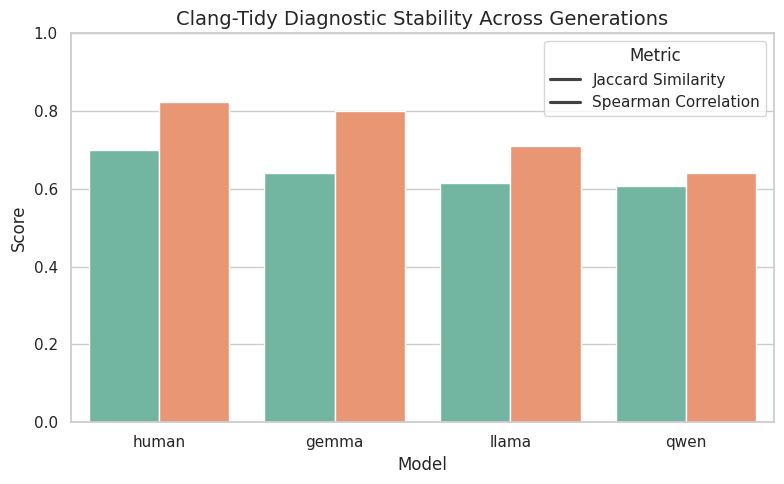

In [22]:
stability_avg = (
    ct_stability.groupby("model")[["jaccard_similarity", "spearman_correlation"]]
                .mean()
                .reset_index()
)

stability_melt = stability_avg.melt(
    id_vars="model",
    value_vars=["jaccard_similarity", "spearman_correlation"],
    var_name="metric",
    value_name="value"
)

stability_melt["model"] = pd.Categorical(stability_melt["model"], categories=model_order, ordered=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=stability_melt,
    x="model",
    y="value",
    hue="metric",
    palette="Set2",
    ax=ax
)

ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("Model", fontsize=12)
ax.set_title("Clang-Tidy Diagnostic Stability Across Generations", fontsize=14)
ax.set_ylim(0, 1)
ax.legend(title="Metric", labels=["Jaccard Similarity", "Spearman Correlation"])

plt.tight_layout()
plt.savefig("../results/figures/clang_tidy_stability.pdf")
plt.savefig("../results/figures/clang_tidy_stability.png", dpi=150)
plt.show()

## CT-F7: Combined Tool Summary (cppcheck CWE + clang-tidy security per file by status)

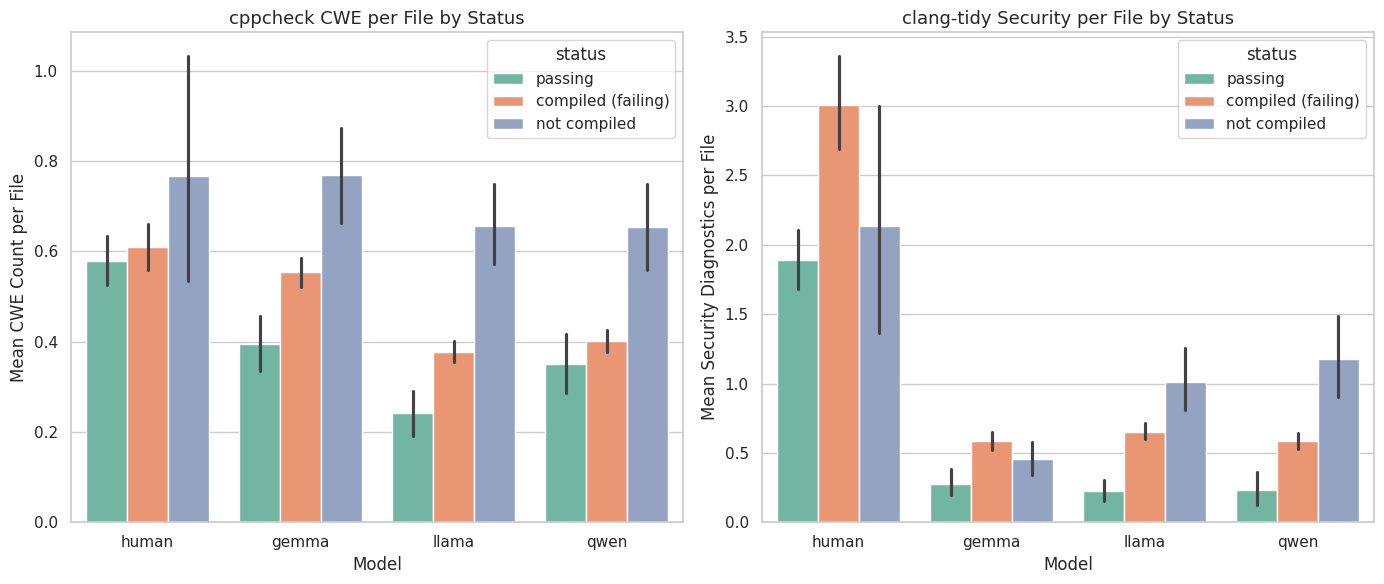

,model,status,cppcheck_cwe_per_file,clang_security_per_file,clang_total_per_file,n_files
0,human,passing,0.579,1.888,7.846,748
1,human,compiled (failing),0.610,3.007,11.655,917
2,human,not compiled,0.767,2.133,17.233,30
3,gemma,passing,0.394,0.279,3.751,269
4,gemma,compiled (failing),0.555,0.583,7.093,1749
5,gemma,not compiled,0.768,0.455,8.382,220
6,llama,passing,0.242,0.225,3.180,289
7,llama,compiled (failing),0.377,0.654,4.722,1983
8,llama,not compiled,0.656,1.013,9.750,224
9,qwen,passing,0.350,0.233,2.587,206


In [23]:
# Side-by-side: cppcheck CWE vs clang-tidy security by model and status
master_combined = master.copy()
master_combined["clang_security"] = master_combined["clang_bugprone"].fillna(0) + master_combined["clang_analyzer"].fillna(0)
master_combined["cwe_count"] = master_combined["cppcheck_cwe_count"].fillna(0)

master_combined["status"] = "not compiled"
master_combined.loc[master_combined["compiled"] == True, "status"] = "compiled (failing)"
master_combined.loc[master_combined["pass_rate"] == 1.0, "status"] = "passing"

status_order = ["passing", "compiled (failing)", "not compiled"]
master_combined["status"] = pd.Categorical(master_combined["status"], categories=status_order, ordered=True)

# Build summary table
tool_rows = []
for model in model_order:
    for status in status_order:
        subset = master_combined[(master_combined["model"] == model) & (master_combined["status"] == status)]
        if len(subset) > 0:
            tool_rows.append({
                "model": model, "status": status,
                "cppcheck_cwe_per_file": round(subset["cwe_count"].mean(), 3),
                "clang_security_per_file": round(subset["clang_security"].mean(), 3),
                "clang_total_per_file": round(subset["clang_total"].mean(), 3),
                "n_files": len(subset)
            })

combined_summary = pd.DataFrame(tool_rows)
combined_summary.to_csv("../results/tables/combined_tool_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=master_combined, x="model", y="cwe_count", hue="status",
            order=model_order, palette="Set2", ax=axes[0], errorbar="ci")
axes[0].set_title("cppcheck CWE per File by Status", fontsize=13)
axes[0].set_ylabel("Mean CWE Count per File")
axes[0].set_xlabel("Model")

sns.barplot(data=master_combined, x="model", y="clang_security", hue="status",
            order=model_order, palette="Set2", ax=axes[1], errorbar="ci")
axes[1].set_title("clang-tidy Security per File by Status", fontsize=13)
axes[1].set_ylabel("Mean Security Diagnostics per File")
axes[1].set_xlabel("Model")

plt.tight_layout()
plt.savefig("../results/figures/tool_comparison.pdf")
plt.savefig("../results/figures/tool_comparison.png", dpi=150)
plt.show()

combined_summary

# Filtered Analysis (Excluding Interactive Problems)

Interactive problems require real-time bidirectional I/O with a judge and cannot be tested offline.
We exclude them to ensure fair comparison across all models.

In [24]:
# Filter out interactive problems from master dataset
EXCLUDED_TAGS = ["interactive"]

# Reload master and explode tags
master = pd.read_csv("../results/raw_csv/master_analysis.csv")

# Identify samples with excluded tags
def has_excluded_tag(tags_str):
    if pd.isna(tags_str):
        return False
    tags = [t.strip() for t in str(tags_str).split("|")]
    return any(t in EXCLUDED_TAGS for t in tags)

master["is_excluded"] = master["tags"].apply(has_excluded_tag)

# Create filtered dataset
master_filtered = master[~master["is_excluded"]].copy()

print(f"Original samples: {len(master)}")
print(f"Excluded (interactive): {master['is_excluded'].sum()}")
print(f"Filtered samples: {len(master_filtered)}")
print(f"\nExcluded by model:")
print(master[master["is_excluded"]].groupby("model").size())

Original samples: 8918
Excluded (interactive): 95
Filtered samples: 8823

Excluded by model:
model
gemma    23
human    18
llama    27
qwen     27
dtype: int64


In [25]:
# Pass rates excluding interactive problems
filtered_pass = master_filtered.groupby("model").agg(
    samples=('sample_id', 'count'),
    passing=('pass_rate', lambda x: (x == 1.0).sum()),
    mean_pass=('pass_rate', 'mean')
).round(3)

filtered_pass["pass_pct"] = (filtered_pass["passing"] / filtered_pass["samples"] * 100).round(1)

# Compare with original
orig_pass = master.groupby("model").agg(
    orig_samples=('sample_id', 'count'),
    orig_passing=('pass_rate', lambda x: (x == 1.0).sum())
)
orig_pass["orig_pass_pct"] = (orig_pass["orig_passing"] / orig_pass["orig_samples"] * 100).round(1)

comparison = filtered_pass.join(orig_pass[["orig_pass_pct"]])
comparison["improvement"] = comparison["pass_pct"] - comparison["orig_pass_pct"]

comparison.to_csv("../results/tables/pass_rate_filtered_vs_original.csv")
print("100% Pass Rate: Original vs Filtered (excl. interactive)")
comparison[["orig_pass_pct", "pass_pct", "improvement"]]

100% Pass Rate: Original vs Filtered (excl. interactive)


,orig_pass_pct,pass_pct,improvement
model,,,
gemma,12.0,12.1,0.1
human,44.1,44.6,0.5
llama,11.6,11.7,0.1
qwen,8.3,8.4,0.1


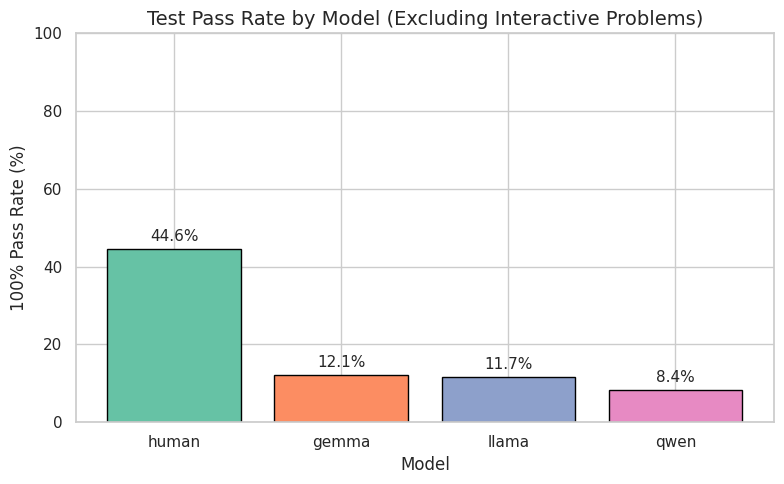

In [26]:
# Bar chart: Filtered pass rates
model_order = ["human", "gemma", "llama", "qwen"]
plot_data = comparison.loc[model_order].reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette("Set2", n_colors=4)

bars = ax.bar(plot_data["model"], plot_data["pass_pct"], color=colors, edgecolor="black")

ax.set_ylabel("100% Pass Rate (%)", fontsize=12)
ax.set_xlabel("Model", fontsize=12)
ax.set_title("Test Pass Rate by Model (Excluding Interactive Problems)", fontsize=14)
ax.set_ylim(0, 100)

for bar, val in zip(bars, plot_data["pass_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{val:.1f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("../results/figures/pass_rate_filtered.pdf")
plt.savefig("../results/figures/pass_rate_filtered.png", dpi=150)
plt.show()

In [27]:
# Tag-wise pass rates (filtered)
master_exploded_filt = master_filtered.assign(
    tag=master_filtered["tags"].str.split("|")
).explode("tags")
master_exploded_filt["tags"] = master_exploded_filt["tags"].str.strip()

# Pass rate by tag and model
tag_pass_filt = master_exploded_filt.groupby(["tags", "model"]).agg(
    total=('sample_id', 'count'),
    passing=('pass_rate', lambda x: (x == 1.0).sum())
).reset_index()
tag_pass_filt["pass_pct"] = (tag_pass_filt["passing"] / tag_pass_filt["total"] * 100).round(1)

# Common tags
common_tags = master_exploded_filt["tags"].value_counts().head(20).index.tolist()
tag_pass_common = tag_pass_filt[tag_pass_filt["tags"].isin(common_tags)]

# Pivot
tag_pivot_filt = tag_pass_common.pivot(index="tags", columns="model", values="pass_pct")
tag_pivot_filt = tag_pivot_filt[["human", "gemma", "llama", "qwen"]]

tag_pivot_filt.to_csv("../results/tables/pass_rate_by_tag_filtered.csv")
print("Pass Rate by Tag (Excluding Interactive):")
tag_pivot_filt.sort_values("human", ascending=False)

Pass Rate by Tag (Excluding Interactive):


model,human,gemma,llama,qwen
tags,,,,
bitmasks|dp,100.0,14.3,20.0,9.5
geometry|math,100.0,8.3,0.0,0.0
implementation,93.1,45.1,42.9,43.7
implementation|strings,91.7,43.8,44.4,33.3
implementation|math,88.9,28.6,36.6,26.8
constructive algorithms|greedy,87.5,0.0,50.0,16.7
dfs and similar|dsu|graphs,87.5,50.0,16.7,33.3
brute force|implementation|strings,87.5,25.0,58.3,33.3
math,86.7,13.6,25.6,11.4


In [28]:
# Human-AI gap analysis (filtered)
tag_pivot_filt["ai_avg"] = tag_pivot_filt[["gemma", "llama", "qwen"]].mean(axis=1)
tag_pivot_filt["human_ai_gap"] = tag_pivot_filt["human"] - tag_pivot_filt["ai_avg"]

gap_sorted = tag_pivot_filt.sort_values("human_ai_gap", ascending=False)

gap_sorted[["human", "ai_avg", "human_ai_gap"]].to_csv(
    "../results/tables/human_ai_gap_filtered.csv"
)

print("Tags with Largest Human-AI Gap (Filtered):")
gap_sorted[["human", "ai_avg", "human_ai_gap"]].head(15)

Tags with Largest Human-AI Gap (Filtered):


model,human,ai_avg,human_ai_gap
tags,,,
geometry|math,100.0,2.766667,97.233333
bitmasks|dp,100.0,14.600000,85.400000
dp,86.4,1.033333,85.366667
math,86.7,16.866667,69.833333
constructive algorithms|math,70.0,4.433333,65.566667
constructive algorithms|greedy,87.5,22.233333,65.266667
implementation|math,88.9,30.666667,58.233333
greedy,65.2,7.800000,57.400000
dfs and similar|dsu|graphs,87.5,33.333333,54.166667


In [29]:
# Summary: Overall filtered statistics
print("="*60)
print("FILTERED ANALYSIS SUMMARY (Excluding Interactive Problems)")
print("="*60)
print(f"\nTotal samples analyzed: {len(master_filtered)}")
print(f"Interactive problems excluded: {master['is_excluded'].sum()}")
print(f"\n100% Pass Rates:")
for model in ["human", "gemma", "llama", "qwen"]:
    pct = comparison.loc[model, "pass_pct"]
    orig = comparison.loc[model, "orig_pass_pct"]
    print(f"  {model}: {pct:.1f}% (was {orig:.1f}%)")
print(f"\nHuman-AI gap (filtered): {comparison.loc['human', 'pass_pct'] - comparison.loc[['gemma', 'llama', 'qwen'], 'pass_pct'].mean():.1f} pp")

FILTERED ANALYSIS SUMMARY (Excluding Interactive Problems)

Total samples analyzed: 8823
Interactive problems excluded: 95

100% Pass Rates:
  human: 44.6% (was 44.1%)
  gemma: 12.1% (was 12.0%)
  llama: 11.7% (was 11.6%)
  qwen: 8.4% (was 8.3%)

Human-AI gap (filtered): 33.9 pp


In [30]:
# Export filtered results to LaTeX
latex_df = comparison[["samples", "passing", "pass_pct"]].copy()
latex_df.columns = ["Samples", "Passing", "Pass Rate (\%)"]

to_latex_booktabs(
    latex_df,
    "pass_rate_filtered.tex",
    "Test Pass Rates by Model (Excluding Interactive Problems)",
    "tab:pass_rate_filtered"
)

NameError: name 'to_latex_booktabs' is not defined

# Reviewer Response Analyses

## Q2: Pipeline Attrition per Model/Generation

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")

master = pd.read_csv("../results/raw_csv/master_analysis.csv")
tests = pd.read_csv("../results/raw_csv/tests_all.csv")
agg_csv = pd.read_csv("../results/raw_csv/agg_per_model_gen.csv")

# pipeline attrition: generated → compiled → had tests → passed all
q2 = tests.groupby(["model", "generation"]).agg(
    total_generated=("sample_id", "count"),
    compiled=("compiled", "sum"),
    had_tests=("has_tests", "sum"),
    timed_out=("timeout", "sum"),
).reset_index()

q2["compile_rate"] = (q2["compiled"] / q2["total_generated"]).round(3)

tpr_data = tests[tests["has_tests"] == 1].copy()
tpr_stats = tpr_data.groupby(["model", "generation"]).agg(
    n_with_tests=("sample_id", "count"),
    mean_tpr=("pass_rate", "mean"),
    all_pass=("pass_rate", lambda x: (x == 1.0).sum()),
    zero_pass=("pass_rate", lambda x: (x == 0.0).sum()),
).reset_index()

q2_full = q2.merge(tpr_stats, on=["model", "generation"])
q2_full["test_coverage"] = (q2_full["had_tests"] / q2_full["total_generated"]).round(3)
q2_full["timeout_rate"] = (q2_full["timed_out"] / q2_full["n_with_tests"]).round(3)
q2_full["mean_tpr"] = q2_full["mean_tpr"].round(3)

q2_full.to_csv("../results/tables/q2_pipeline_attrition.csv", index=False)
q2_full

In [ ]:
# Stacked bar: pipeline attrition (AI models only)
ai_only = q2_full[~q2_full["model"].isin(["human"])].copy()
ai_only["label"] = ai_only["model"] + "/" + ai_only["generation"]
ai_only = ai_only.sort_values(["model", "generation"])

not_compiled = ai_only["total_generated"] - ai_only["compiled"]
compiled_no_tests = ai_only["compiled"] - ai_only["had_tests"]
had_tests_not_pass = ai_only["n_with_tests"] - ai_only["all_pass"]
all_passed = ai_only["all_pass"]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(ai_only))
w = 0.6
colors = sns.color_palette("Set2", n_colors=4)

ax.bar(x, not_compiled.values, w, label="Failed to compile", color=colors[3])
ax.bar(x, compiled_no_tests.values, w, bottom=not_compiled.values,
       label="Compiled, no tests", color=colors[1])
ax.bar(x, had_tests_not_pass.values, w,
       bottom=(not_compiled + compiled_no_tests).values,
       label="Had tests, not all passed", color=colors[0])
ax.bar(x, all_passed.values, w,
       bottom=(not_compiled + compiled_no_tests + had_tests_not_pass).values,
       label="All tests passed", color=colors[2])

ax.set_xticks(x)
ax.set_xticklabels(ai_only["label"].values, rotation=45, ha="right")
ax.set_ylabel("Number of Programs", fontsize=12)
ax.set_title("Pipeline Attrition: Generation to All Tests Passed", fontsize=14)
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig("../results/figures/q2_pipeline_attrition.pdf")
plt.savefig("../results/figures/q2_pipeline_attrition.png", dpi=150)
plt.show()

## Q4: Extraction & Exclusion Rates

In [ ]:
total_instructions = 851

q4_rows = []
for _, row in agg_csv.iterrows():
    generated = row["total_files"]
    excluded = total_instructions - generated
    q4_rows.append({
        "model": row["model"],
        "generation": row["gen"],
        "total_instructions": total_instructions,
        "extracted_programs": int(generated),
        "excluded": int(excluded),
        "exclusion_rate": round(excluded / total_instructions, 3),
        "compiled": int(row["compiled_count"]),
        "compile_rate_of_extracted": round(row["compile_rate"], 3),
    })

q4 = pd.DataFrame(q4_rows)
q4.to_csv("../results/tables/q4_extraction_exclusion.csv", index=False)
q4

## Q5: Top 10 CWEs by Frequency with Severity

In [ ]:
# MITRE CWE severity mapping
cwe_severity = {
    "CWE-119": ("Buffer Overflow", "High", True),
    "CWE-190": ("Integer Overflow", "High", True),
    "CWE-197": ("Numeric Truncation", "Medium", False),
    "CWE-252": ("Unchecked Return Value", "Medium", False),
    "CWE-369": ("Divide By Zero", "Medium", False),
    "CWE-391": ("Unchecked Error Condition", "Low", False),
    "CWE-398": ("Code Quality (Variable Scope)", "Low", False),
    "CWE-457": ("Use of Uninitialized Variable", "High", True),
    "CWE-476": ("NULL Pointer Dereference", "High", True),
    "CWE-477": ("Obsolete Function", "Low", False),
    "CWE-561": ("Dead Code", "Low", False),
    "CWE-562": ("Return of Stack Variable Address", "High", False),
    "CWE-563": ("Unused Variable Assignment", "Low", False),
    "CWE-570": ("Expression Always False", "Medium", False),
    "CWE-571": ("Expression Always True", "Medium", False),
    "CWE-628": ("Function Call Wrong Args", "Medium", False),
    "CWE-664": ("Improper Resource Control", "Medium", False),
    "CWE-665": ("Improper Initialization", "Medium", False),
    "CWE-686": ("Function Call Wrong Arg Type", "Medium", False),
    "CWE-704": ("Incorrect Type Conversion", "Medium", False),
    "CWE-758": ("Undefined Behavior", "High", False),
    "CWE-762": ("Mismatched Memory Routines", "High", False),
    "CWE-772": ("Missing Resource Release", "Medium", False),
    "CWE-783": ("Operator Precedence Error", "Medium", False),
    "CWE-786": ("Buffer Under-read", "High", True),
    "CWE-788": ("Buffer Over-read", "High", True),
    "CWE-825": ("Expired Pointer Dereference", "High", False),
}

cwe_prev = pd.read_csv("../results/raw_csv/cwe_prevalence.csv")

ai_cwes = (
    cwe_prev[cwe_prev["model"] != "human"]
    .groupby("cwe")
    .agg(ai_total_findings=("total_findings", "sum"),
         ai_files_affected=("files_affected", "sum"))
    .reset_index()
)

human_cwes = (
    cwe_prev[cwe_prev["model"] == "human"]
    .groupby("cwe")
    .agg(human_total_findings=("total_findings", "sum"),
         human_files_affected=("files_affected", "sum"))
    .reset_index()
)

q5 = ai_cwes.merge(human_cwes, on="cwe", how="outer").fillna(0)
q5["description"] = q5["cwe"].map(lambda x: cwe_severity.get(x, ("Unknown", "Unknown", False))[0])
q5["severity"] = q5["cwe"].map(lambda x: cwe_severity.get(x, ("Unknown", "Unknown", False))[1])
q5["mitre_top25"] = q5["cwe"].map(lambda x: cwe_severity.get(x, ("Unknown", "Unknown", False))[2])

q5 = q5.sort_values("ai_total_findings", ascending=False)
q5_top10 = q5.head(10).copy()
for col in ["ai_total_findings", "ai_files_affected", "human_total_findings", "human_files_affected"]:
    q5_top10[col] = q5_top10[col].astype(int)

q5_top10.to_csv("../results/tables/q5_top10_cwe_with_severity.csv", index=False)
q5_top10

In [ ]:
# Per-model breakdown of top-10 CWEs
top10_cwes = q5_top10["cwe"].tolist()
cwe_by_model = cwe_prev[cwe_prev["cwe"].isin(top10_cwes)].copy()

q5_pivot = cwe_by_model.pivot_table(
    index="cwe", columns="model", values="total_findings", fill_value=0
).astype(int)

q5_pivot["description"] = q5_pivot.index.map(
    lambda x: cwe_severity.get(x, ("?", "?", False))[0]
)
q5_pivot["severity"] = q5_pivot.index.map(
    lambda x: cwe_severity.get(x, ("?", "?", False))[1]
)
q5_pivot = q5_pivot[["description", "severity", "gemma", "llama", "qwen", "human"]]
q5_pivot = q5_pivot.sort_values("gemma", ascending=False)

q5_pivot.to_csv("../results/tables/q5_cwe_by_model_with_severity.csv")
q5_pivot

In [ ]:
# Grouped bar chart: top-10 CWEs by model with severity-coloured labels
model_order = ["gemma", "llama", "qwen", "human"]
colors = sns.color_palette("Set2", n_colors=4)
x = np.arange(len(top10_cwes))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model, color) in enumerate(zip(model_order, colors)):
    vals = []
    for cwe in top10_cwes:
        row = cwe_by_model[(cwe_by_model["cwe"] == cwe) & (cwe_by_model["model"] == model)]
        vals.append(row["total_findings"].values[0] if len(row) > 0 else 0)
    ax.bar(x + i * width, vals, width, label=model.capitalize(), color=color)

sev_colors = {"High": "red", "Medium": "orange", "Low": "gray"}
labels = [f"{c}\n({cwe_severity.get(c, ('?','?',False))[0][:15]})" for c in top10_cwes]

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)

for i, cwe in enumerate(top10_cwes):
    sev = cwe_severity.get(cwe, ("?", "?", False))[1]
    ax.get_xticklabels()[i].set_color(sev_colors.get(sev, "black"))

ax.set_ylabel("Total Findings", fontsize=12)
ax.set_title("Top 10 CWE Types by Frequency (label colour = severity)", fontsize=14)
ax.legend()

plt.tight_layout()
plt.savefig("../results/figures/q5_top10_cwe_by_model_severity.pdf")
plt.savefig("../results/figures/q5_top10_cwe_by_model_severity.png", dpi=150)
plt.show()

In [ ]:
# Severity aggregation
sev_agg = (
    q5.groupby("severity")
      .agg(n_cwe_types=("cwe", "count"),
           ai_total=("ai_total_findings", "sum"),
           ai_files=("ai_files_affected", "sum"),
           human_total=("human_total_findings", "sum"),
           human_files=("human_files_affected", "sum"))
      .reset_index()
      .sort_values("ai_total", ascending=False)
)

sev_agg.to_csv("../results/tables/q5_severity_aggregation.csv", index=False)
sev_agg

## Q8: Per-Problem Paired Comparisons (Human vs AI)

In [ ]:
# Human per-problem averages
human_df = master[master["model"] == "human"].copy()
human_agg = human_df.groupby("problem_key").agg(
    human_cppcheck_total=("cppcheck_total", "mean"),
    human_cppcheck_cwe=("cppcheck_cwe_count", "mean"),
    human_clang_total=("clang_total", "mean"),
    human_clang_bugprone=("clang_bugprone", "mean"),
    human_clang_analyzer=("clang_analyzer", "mean"),
    human_pass_rate=("pass_rate", "mean"),
    human_n=("sample_id", "count"),
).reset_index()

# AI per-problem averages (all models pooled)
ai_df = master[master["model"] != "human"].copy()
ai_agg = ai_df.groupby("problem_key").agg(
    ai_cppcheck_total=("cppcheck_total", "mean"),
    ai_cppcheck_cwe=("cppcheck_cwe_count", "mean"),
    ai_clang_total=("clang_total", "mean"),
    ai_clang_bugprone=("clang_bugprone", "mean"),
    ai_clang_analyzer=("clang_analyzer", "mean"),
    ai_pass_rate=("pass_rate", "mean"),
    ai_n=("sample_id", "count"),
).reset_index()

paired = human_agg.merge(ai_agg, on="problem_key", how="inner")
print(f"Paired problems (both human and AI): {len(paired)}")

metrics = [
    ("cppcheck_total", "Cppcheck Total Warnings"),
    ("cppcheck_cwe", "Cppcheck CWE Count"),
    ("clang_total", "Clang-Tidy Total Diagnostics"),
    ("clang_bugprone", "Clang-Tidy Bugprone"),
    ("clang_analyzer", "Clang-Tidy Analyzer"),
]

paired_stats = []
for metric, label in metrics:
    h = paired[f"human_{metric}"]
    a = paired[f"ai_{metric}"]
    diff = h - a
    t_stat, p_val = stats.ttest_rel(h, a)
    paired_stats.append({
        "metric": label,
        "human_mean": round(h.mean(), 3),
        "ai_mean": round(a.mean(), 3),
        "mean_diff_h_minus_ai": round(diff.mean(), 3),
        "std_diff": round(diff.std(), 3),
        "t_statistic": round(t_stat, 3),
        "p_value": f"{p_val:.2e}",
        "n_problems": len(paired),
    })

q8 = pd.DataFrame(paired_stats)
q8.to_csv("../results/tables/q8_paired_comparison.csv", index=False)
q8

In [ ]:
# Per-model paired comparison
ai_per_model = ai_df.groupby(["model", "problem_key"]).agg(
    ai_cppcheck_total=("cppcheck_total", "mean"),
    ai_cppcheck_cwe=("cppcheck_cwe_count", "mean"),
    ai_clang_total=("clang_total", "mean"),
    ai_clang_bugprone=("clang_bugprone", "mean"),
    ai_clang_analyzer=("clang_analyzer", "mean"),
    ai_pass_rate=("pass_rate", "mean"),
).reset_index()

rows = []
for model in ["gemma", "llama", "qwen"]:
    model_ai = ai_per_model[ai_per_model["model"] == model]
    p = human_agg.merge(model_ai, on="problem_key", how="inner", suffixes=("", "_m"))
    for metric, label in metrics:
        h = p[f"human_{metric}"]
        a = p[f"ai_{metric}"]
        diff = h - a
        t_stat, p_val = stats.ttest_rel(h, a)
        rows.append({
            "model": model.capitalize(),
            "metric": label,
            "human_mean": round(h.mean(), 3),
            "model_mean": round(a.mean(), 3),
            "mean_diff": round(diff.mean(), 3),
            "p_value": f"{p_val:.2e}",
            "n": len(p),
        })

q8b = pd.DataFrame(rows)
q8b.to_csv("../results/tables/q8_paired_by_model.csv", index=False)
q8b

In [ ]:
# Scatter: per-problem Human vs AI warning counts
scatter_metrics = [
    ("cppcheck_total", "Cppcheck Total"),
    ("clang_total", "Clang-Tidy Total"),
    ("clang_bugprone", "Clang-Tidy Bugprone"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (metric, label) in zip(axes, scatter_metrics):
    h = paired[f"human_{metric}"]
    a = paired[f"ai_{metric}"]
    ax.scatter(h, a, alpha=0.3, s=15, color="steelblue")
    max_val = max(h.max(), a.max())
    ax.plot([0, max_val], [0, max_val], "r--", alpha=0.5, label="y=x")
    r, p = stats.pearsonr(h, a)
    ax.set_xlabel(f"Human {label}", fontsize=12)
    ax.set_ylabel(f"AI {label}", fontsize=12)
    ax.set_title(f"{label}\n(r={r:.3f}, p={p:.2e})", fontsize=14)
    ax.legend()

plt.suptitle("Per-Problem Paired Comparison: Human vs AI Warning Counts", y=1.02)
plt.tight_layout()
plt.savefig("../results/figures/q8_paired_scatter.pdf")
plt.savefig("../results/figures/q8_paired_scatter.png", dpi=150)
plt.show()

## Q9: Jaccard Similarity of Warning Sets Across Generations

In [ ]:
cppcheck_det = pd.read_csv("../results/raw_csv/cppcheck_detailed.csv")
clang_det = pd.read_csv("../results/raw_csv/clang_tidy_detailed.csv")


def jaccard(set1, set2):
    if len(set1) == 0 and len(set2) == 0:
        return 1.0
    union = set1 | set2
    return len(set1 & set2) / len(union) if len(union) > 0 else 0.0


# CWE sets per (model, generation, problem_key)
cwe_sets = (
    cppcheck_det[cppcheck_det["model"] != "human"]
    .groupby(["model", "generation", "problem_key"])["cwe"]
    .apply(lambda x: set(x.dropna().astype(str)))
    .reset_index()
)
cwe_sets.columns = ["model", "generation", "problem_key", "cwe_set"]

# Clang-tidy category sets
clang_cat_sets = (
    clang_det[clang_det["model"] != "human"]
    .groupby(["model", "gen", "problem_key"])["category"]
    .apply(lambda x: set(x.dropna()))
    .reset_index()
)
clang_cat_sets.columns = ["model", "generation", "problem_key", "clang_cat_set"]

# Clang-tidy diagnostic name sets
clang_diag_sets = (
    clang_det[clang_det["model"] != "human"]
    .groupby(["model", "gen", "problem_key"])["diagnostic_name"]
    .apply(lambda x: set(x.dropna()))
    .reset_index()
)
clang_diag_sets.columns = ["model", "generation", "problem_key", "clang_diag_set"]

gen_pairs = [("gen_1", "gen_2"), ("gen_1", "gen_3"), ("gen_2", "gen_3")]

jaccard_results = []
for model in ["gemma", "llama", "qwen"]:
    for g1, g2 in gen_pairs:
        # CWE Jaccard
        s1 = cwe_sets[(cwe_sets["model"] == model) & (cwe_sets["generation"] == g1)]
        s2 = cwe_sets[(cwe_sets["model"] == model) & (cwe_sets["generation"] == g2)]
        merged = s1.merge(s2, on="problem_key", suffixes=("_1", "_2"))
        cwe_jacs = (merged.apply(lambda r: jaccard(r["cwe_set_1"], r["cwe_set_2"]), axis=1)
                    if len(merged) > 0 else pd.Series([0]))

        # Clang category Jaccard
        c1 = clang_cat_sets[(clang_cat_sets["model"] == model) & (clang_cat_sets["generation"] == g1)]
        c2 = clang_cat_sets[(clang_cat_sets["model"] == model) & (clang_cat_sets["generation"] == g2)]
        c_merged = c1.merge(c2, on="problem_key", suffixes=("_1", "_2"))
        clang_cat_jacs = (c_merged.apply(lambda r: jaccard(r["clang_cat_set_1"], r["clang_cat_set_2"]), axis=1)
                          if len(c_merged) > 0 else pd.Series([0]))

        # Clang diagnostic Jaccard
        d1 = clang_diag_sets[(clang_diag_sets["model"] == model) & (clang_diag_sets["generation"] == g1)]
        d2 = clang_diag_sets[(clang_diag_sets["model"] == model) & (clang_diag_sets["generation"] == g2)]
        d_merged = d1.merge(d2, on="problem_key", suffixes=("_1", "_2"))
        clang_diag_jacs = (d_merged.apply(lambda r: jaccard(r["clang_diag_set_1"], r["clang_diag_set_2"]), axis=1)
                           if len(d_merged) > 0 else pd.Series([0]))

        jaccard_results.append({
            "model": model.capitalize(),
            "gen_pair": f"{g1} vs {g2}",
            "cwe_jaccard_mean": round(cwe_jacs.mean(), 3),
            "cwe_jaccard_median": round(cwe_jacs.median(), 3),
            "n_problems_cwe": len(merged),
            "clang_cat_jaccard_mean": round(clang_cat_jacs.mean(), 3),
            "clang_diag_jaccard_mean": round(clang_diag_jacs.mean(), 3),
            "n_problems_clang": len(c_merged),
        })

q9 = pd.DataFrame(jaccard_results)
q9.to_csv("../results/tables/q9_jaccard_warning_stability.csv", index=False)
q9

In [ ]:
# Histograms: per-task CWE Jaccard similarity across generations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, model in enumerate(["gemma", "llama", "qwen"]):
    ax = axes[idx]
    for g1, g2 in gen_pairs:
        s1 = cwe_sets[(cwe_sets["model"] == model) & (cwe_sets["generation"] == g1)]
        s2 = cwe_sets[(cwe_sets["model"] == model) & (cwe_sets["generation"] == g2)]
        merged = s1.merge(s2, on="problem_key", suffixes=("_1", "_2"))
        if len(merged) > 0:
            jacs = merged.apply(lambda r: jaccard(r["cwe_set_1"], r["cwe_set_2"]), axis=1)
            ax.hist(jacs, bins=20, alpha=0.5, label=f"{g1} vs {g2}", density=True)
    ax.set_xlabel("Jaccard Similarity", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_title(f"{model.capitalize()}: CWE Set Stability", fontsize=14)
    ax.legend(fontsize=8)

plt.suptitle("Per-Task CWE Set Jaccard Similarity Across Generations", y=1.02)
plt.tight_layout()
plt.savefig("../results/figures/q9_jaccard_cwe_distributions.pdf")
plt.savefig("../results/figures/q9_jaccard_cwe_distributions.png", dpi=150)
plt.show()

## Q11: Sensitivity Analysis (Excluding Inconclusive + Clang-Tidy)

In [ ]:
# CWE prevalence: full vs excluding style-only CWEs vs clang-tidy security
full_cwe = (
    master.groupby(["model", "generation"])
          .agg(n_analyzed=("sample_id", "count"),
               n_with_cwe=("cppcheck_has_cwe", "sum"))
          .reset_index()
)
full_cwe["prevalence_full"] = (full_cwe["n_with_cwe"] / full_cwe["n_analyzed"]).round(3)

# Exclude style-only CWEs (CWE-398, CWE-563)
style_cwes = {"398", "563", "398.0", "563.0"}
non_style_cwe = cppcheck_det[~cppcheck_det["cwe"].astype(str).isin(style_cwes)].copy()
non_style_programs = (
    non_style_cwe.groupby(["model", "generation", "sample_id"]).size().reset_index()
)
non_style_programs.columns = ["model", "generation", "sample_id", "n_findings"]

non_style_by_mg = (
    non_style_programs.groupby(["model", "generation"])["sample_id"]
                      .nunique()
                      .reset_index()
)
non_style_by_mg.columns = ["model", "generation", "n_with_non_style_cwe"]

sensitivity = full_cwe.merge(non_style_by_mg, on=["model", "generation"], how="left")
sensitivity["n_with_non_style_cwe"] = sensitivity["n_with_non_style_cwe"].fillna(0).astype(int)
sensitivity["prevalence_excl_style"] = (
    sensitivity["n_with_non_style_cwe"] / sensitivity["n_analyzed"]
).round(3)

# Clang-tidy security prevalence
master["clang_security"] = master["clang_bugprone"].fillna(0) + master["clang_analyzer"].fillna(0)
clang_sec = (
    master.groupby(["model", "generation"])
          .agg(n_with_clang_security=("clang_security", lambda x: (x > 0).sum()))
          .reset_index()
)

sensitivity = sensitivity.merge(clang_sec, on=["model", "generation"], how="left")
sensitivity["prevalence_clang_security"] = (
    sensitivity["n_with_clang_security"] / sensitivity["n_analyzed"]
).round(3)

sensitivity.to_csv("../results/tables/q11_sensitivity_analysis.csv", index=False)
sensitivity

In [ ]:
# Bar chart: prevalence under different criteria (AI only)
ai_sens = sensitivity[~sensitivity["model"].isin(["human"])].copy()
ai_sens["label"] = ai_sens["model"] + "/" + ai_sens["generation"]

x = np.arange(len(ai_sens))
w = 0.25
colors = sns.color_palette("Set2", n_colors=3)

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - w, ai_sens["prevalence_full"].values, w,
       label="Cppcheck (all CWEs)", color=colors[0])
ax.bar(x, ai_sens["prevalence_excl_style"].values, w,
       label="Cppcheck (excl. style CWEs)", color=colors[1])
ax.bar(x + w, ai_sens["prevalence_clang_security"].values, w,
       label="Clang-Tidy (bugprone+analyzer)", color=colors[2])

ax.set_xticks(x)
ax.set_xticklabels(ai_sens["label"].values, rotation=45, ha="right")
ax.set_ylabel("Fraction of Programs with >= 1 Finding", fontsize=12)
ax.set_title("Sensitivity Analysis: Vulnerability Prevalence by Tool and Criteria", fontsize=14)
ax.legend()
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig("../results/figures/q11_sensitivity_analysis.pdf")
plt.savefig("../results/figures/q11_sensitivity_analysis.png", dpi=150)
plt.show()

In [ ]:
# Tool agreement: cppcheck CWE vs clang-tidy security
master["has_cppcheck_cwe"] = master["cppcheck_has_cwe"].fillna(0).astype(bool)
master["has_clang_security"] = master["clang_security"] > 0

model_order = ["human", "gemma", "llama", "qwen"]
agreement_rows = []
for model in model_order:
    m = master[master["model"] == model]
    both = ((m["has_cppcheck_cwe"]) & (m["has_clang_security"])).sum()
    cpp_only = ((m["has_cppcheck_cwe"]) & (~m["has_clang_security"])).sum()
    clang_only = ((~m["has_cppcheck_cwe"]) & (m["has_clang_security"])).sum()
    neither = ((~m["has_cppcheck_cwe"]) & (~m["has_clang_security"])).sum()
    total = len(m)
    agreement_rows.append({
        "model": model.capitalize(),
        "both_tools": both,
        "cppcheck_only": cpp_only,
        "clang_only": clang_only,
        "neither": neither,
        "total": total,
        "agreement_rate": round((both + neither) / total, 3),
    })

q11_agree = pd.DataFrame(agreement_rows)
q11_agree.to_csv("../results/tables/q11_tool_agreement.csv", index=False)
q11_agree

## Q12: Correlation Between TPR and Static Warning Presence

In [ ]:
# Program-level correlation: pass_rate vs warning counts
tested = master[master["pass_rate"].notna()].copy()

corr_metrics = [
    ("cppcheck_total", "Cppcheck Total"),
    ("cppcheck_cwe_count", "Cppcheck CWE Count"),
    ("clang_total", "Clang-Tidy Total"),
    ("clang_bugprone", "Clang-Tidy Bugprone"),
    ("clang_analyzer", "Clang-Tidy Analyzer"),
]

corr_results = []
for col, label in corr_metrics:
    valid = tested[["pass_rate", col]].dropna()
    r_pearson, p_pearson = stats.pearsonr(valid["pass_rate"], valid[col])
    r_spearman, p_spearman = stats.spearmanr(valid["pass_rate"], valid[col])
    corr_results.append({
        "metric": label,
        "pearson_r": round(r_pearson, 4),
        "pearson_p": f"{p_pearson:.2e}",
        "spearman_rho": round(r_spearman, 4),
        "spearman_p": f"{p_spearman:.2e}",
        "n": len(valid),
    })

q12_overall = pd.DataFrame(corr_results)
q12_overall.to_csv("../results/tables/q12_tpr_warning_correlation_overall.csv", index=False)
q12_overall

In [ ]:
# Per-model Spearman correlation
per_model_rows = []
for model in ["gemma", "llama", "qwen", "human"]:
    m = tested[tested["model"] == model]
    for col, label in corr_metrics:
        valid = m[["pass_rate", col]].dropna()
        if len(valid) > 2:
            r, p = stats.spearmanr(valid["pass_rate"], valid[col])
            per_model_rows.append({
                "model": model.capitalize(),
                "metric": label,
                "spearman_rho": round(r, 4),
                "p_value": f"{p:.2e}",
                "n": len(valid),
            })

q12_by_model = pd.DataFrame(per_model_rows)
q12_by_model.to_csv("../results/tables/q12_tpr_warning_correlation_by_model.csv", index=False)
q12_by_model

In [ ]:
# Mean warning counts by test pass status
tested["status"] = tested["pass_rate"].apply(
    lambda x: "all_pass" if x == 1.0 else ("partial" if x > 0 else "zero_pass")
)

status_rows = []
for model in ["gemma", "llama", "qwen", "human"]:
    m = tested[tested["model"] == model]
    for status in ["all_pass", "partial", "zero_pass"]:
        s = m[m["status"] == status]
        if len(s) > 0:
            status_rows.append({
                "model": model.capitalize(),
                "status": status,
                "n": len(s),
                "mean_cppcheck_total": round(s["cppcheck_total"].mean(), 3),
                "mean_cppcheck_cwe": round(s["cppcheck_cwe_count"].mean(), 3),
                "mean_clang_total": round(s["clang_total"].mean(), 3),
                "mean_clang_bugprone": round(s["clang_bugprone"].mean(), 3),
                "mean_clang_analyzer": round(s["clang_analyzer"].mean(), 3),
            })

q12_status = pd.DataFrame(status_rows)
q12_status.to_csv("../results/tables/q12_warnings_by_pass_status.csv", index=False)
q12_status

In [ ]:
# Violin plots: warning counts by pass status
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, model in enumerate(["gemma", "llama", "qwen", "human"]):
    ax = axes[idx // 2, idx % 2]
    m = tested[tested["model"] == model].copy()
    m["pass_status"] = m["pass_rate"].apply(
        lambda x: "All Passed" if x == 1.0 else ("Partial" if x > 0 else "None Passed")
    )

    data_by_status = []
    labels = []
    for status in ["All Passed", "Partial", "None Passed"]:
        d = m[m["pass_status"] == status]["clang_total"].dropna()
        if len(d) > 0:
            data_by_status.append(d.values)
            labels.append(f"{status}\n(n={len(d)})")

    if data_by_status:
        vp = ax.violinplot(data_by_status, showmeans=True, showmedians=True)
        ax.set_xticks(range(1, len(labels) + 1))
        ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("Clang-Tidy Total Diagnostics", fontsize=12)
    ax.set_title(f"{model.capitalize()}", fontsize=14)

plt.suptitle("Clang-Tidy Diagnostics by Test Pass Status", y=1.01)
plt.tight_layout()
plt.savefig("../results/figures/q12_warnings_by_status_violin.pdf")
plt.savefig("../results/figures/q12_warnings_by_status_violin.png", dpi=150)
plt.show()

In [ ]:
# Scatter: pass_rate vs clang_total (AI models)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, model in enumerate(["gemma", "llama", "qwen"]):
    ax = axes[idx]
    m = tested[tested["model"] == model][["pass_rate", "clang_total"]].dropna()
    ax.scatter(m["pass_rate"], m["clang_total"], alpha=0.2, s=10, color="steelblue")

    z = np.polyfit(m["pass_rate"], m["clang_total"], 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(0, 1, 100)
    ax.plot(x_line, p_line(x_line), "r-", alpha=0.7, linewidth=2)

    r, p = stats.spearmanr(m["pass_rate"], m["clang_total"])
    ax.set_xlabel("Test Pass Rate", fontsize=12)
    ax.set_ylabel("Clang-Tidy Total Diagnostics", fontsize=12)
    ax.set_title(f"{model.capitalize()} (rho={r:.3f}, p={p:.2e})", fontsize=14)

plt.suptitle("Test Pass Rate vs Static Analysis Warnings", y=1.02)
plt.tight_layout()
plt.savefig("../results/figures/q12_tpr_vs_clang.pdf")
plt.savefig("../results/figures/q12_tpr_vs_clang.png", dpi=150)
plt.show()

## Q3: Investigation of gen_2 TPR Drops

In [ ]:
# Overall TPR by model/generation
tpr_summary = (
    tested.groupby(["model", "generation"])
          .agg(n=("pass_rate", "count"),
               mean_tpr=("pass_rate", "mean"),
               median_tpr=("pass_rate", "median"),
               std_tpr=("pass_rate", "std"),
               pct_zero=("pass_rate", lambda x: (x == 0).mean()),
               pct_all_pass=("pass_rate", lambda x: (x == 1.0).mean()))
          .reset_index()
          .round(3)
)

tpr_summary

In [ ]:
# Generation-level comparison: compile rate, test coverage, timeout rate
gen_comparison = (
    tests.groupby(["model", "generation"])
         .agg(n=("sample_id", "count"),
              compile_rate=("compiled", "mean"),
              test_coverage=("has_tests", "mean"),
              timeout_rate=("timeout", "mean"),
              mean_total_tests=("total_tests", lambda x: x[x > 0].mean()))
         .reset_index()
         .round(3)
)

gen_comparison.to_csv("../results/tables/q3_gen_comparison.csv", index=False)
gen_comparison